# Plots

In [ ]:
from settings_and_functions import *

# Compute combined uncertainty

In [ ]:
# Name, STD vs GNSS

ds_grouped = xr.open_dataset('_temp_/ds_grouped_2.nc') 

ds_grouped['datatype'][np.isnan(ds_grouped['datatype'])]=8
ds_grouped['datatype'][np.isnan(ds_grouped['VLM_map_InSAR6']) & (ds_grouped['datatype']==8)]=9
ds_grouped['VLM_map_InSAR6_syst_uncertainty_GIA'] = copy.deepcopy(ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'].fillna(0)*0)
ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'] = copy.deepcopy(ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'].fillna(0)*0)
ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'][(ds_grouped['datatype']==9)] = 0
ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'][(ds_grouped['datatype']==8)] = 0
for k, (name, value) in settings['datatypes_info'].items():
    mask = ds_grouped['datatype'] == int(k)
    ds_grouped['VLM_map_InSAR6_syst_uncertainty_GIA'][mask] = value/1000.

# assumption no spatial uncertainty for GNSS 
# rob_uncertainty ~ spatial uncertainty
ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'][ds_grouped['datatype']==5] = 0

# spatial + formal + systematic
ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'] = np.sqrt(ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'].fillna(0)**2 + ds_grouped['VLM_map_InSAR6_uncertainty_GIA'].fillna(0)**2+ ds_grouped['VLM_map_InSAR6_syst_uncertainty_GIA'].fillna(0)**2)


# Save data

In [ ]:
ds_grouped['datatype_show'] = copy.deepcopy(ds_grouped['datatype'])
ds_grouped['datatype_show'][ds_grouped['datatype']==5]=7
ds_grouped['datatype_show'][ds_grouped['datatype']==7]=6
ds_grouped['datatype_show'][ds_grouped['datatype']==6]=5
data_types = settings['datatypes_info']
rename_ = {'VLM_map_InSAR'+settings['Version']+'_GIA':'OE24_GPS_InSAR_GIA','VLM_map_InSAR6_combined_uncertainty_GIA':'OE24_GPS_InSAR_GIA_un','VLM_map':'OE24','VLM_map_uncertainty':'OE24_un'}

ds_group_save = copy.deepcopy(ds_grouped[['VLM_map_InSAR'+settings['Version']+'_GIA','VLM_map_InSAR6_combined_uncertainty_GIA','VLM_map','VLM_map_uncertainty','GIA','GIA_un','d City subsidence only','c Delta subsidence only','pop_below_10p0']].rename(rename_))


for var in ['OE24_GPS_InSAR_GIA','OE24_GPS_InSAR_GIA_un','OE24','OE24_un','d City subsidence only','c Delta subsidence only']:
    ds_group_save[var] = ds_group_save[var]*1000.

ds_group_save['OE24_GPS_InSAR_GIA'].attrs = {'long_name':'Hybrid VLM estimate based on OE24, GPS, InSAR and GIA data', 'units':'mm/year','sources':'Oelsmann et al., 24; Ohenhen et al., 2024, 2025; Shirzaei et al., 2021; Caron et al., 2018; Blewitt et al., 2016'}
ds_group_save['OE24_GPS_InSAR_GIA_un'].attrs = {'long_name':'Hybrid VLM uncertainties based on OE24, GPS, InSAR (formal, cross-validation, and spatial uncertainties) and GIA data', 'units':'mm/year','sources':'Oelsmann et al., 24; Ohenhen et al., 2024, 2025; Shirzaei et al., 2021; Caron et al., 2018; Blewitt et al., 2016'}

ds_group_save['OE24'].attrs = {'long_name':'linear VLM estimates based on OE24', 'units':'mm/year','sources':'Oelsmann et al., 24'}
ds_group_save['OE24_un'].attrs = {'long_name':'linear VLM uncertainty estimate based on OE24', 'units':'mm/year','sources':'Oelsmann et al., 24'}

ds_group_save['GIA'].attrs = {'long_name':'GIA solid earth deformation', 'units':'mm/year','sources':'Caron et al., 2018'}
ds_group_save['GIA_un'].attrs = {'long_name':'GIA solid earth deformation uncertainties', 'units':'mm/year','sources':'Caron et al., 2018'}

ds_group_save['d City subsidence only']=ds_group_save['d City subsidence only']*-1
ds_group_save['c Delta subsidence only']=ds_group_save['c Delta subsidence only']*-1

ds_group_save['d City subsidence only'].attrs = {'long_name':'City subsidence estimate from NI21', 'units':'mm/year','sources':'Nicholls et al., 2021'}
ds_group_save['c Delta subsidence only'].attrs = {'long_name':'Delta subsidence estimate from NI21', 'units':'mm/year','sources':'Nicholls et al., 2021'}
ds_group_save['pop_below_10p0'].attrs = {'long_name':'Population living below 10 m from NI21', 'units':'number of people','sources':'Nicholls et al., 2021'}

ds_group_save.attrs={'info':'Data supplement to submitted manuscript - Subsidence more than doubles sea-level rise today along densely populated coasts - variables interpolated on the DIVA grid','authors': 'Julius Oelsmann, Robert J. Nicholls, Daniel Lincke, Marta Marcos, Manoochehr Shirzaei, Laura Sánchez, Leonard Ohenhen, Denise Dettmering, Jochen Hinkel, Benjamin P. Horton, Florian Seitz','sources':'see manuscript references and methods'}
ds_group_save['datatype']=copy.deepcopy(ds_grouped['datatype_show'])
ds_group_save['datatype'].attrs = {'long_name':'Data type used for VLM estimate','sources':'see manuscript references and methods','values':str(data_types)}
ds_group_save.to_netcdf(settings['output_data']+'Global_VLM_data_Oelsmann_2025_data_supplement.nc')


# Load additional datasets for Figure 1 [Delta, City, EGMS, USA, NZ, ...]

In [ ]:
dir_delta = settings['data_in']+'/InSAR_Deltas/'
file_nz_grid = settings['data_in']+"InSAR_NZ/NZ_InSAR_2003-2011_GRL.txt"
dir_shirzaei = settings['data_in']+'/InSAR_Cities/'

# New zealand 2D grid
# columns based on the file header shown
cols = [
    "lon",
    "lat",
    "LOS_rate_mm_yr",
    "LOS_sigma_mm_yr",
    "vertical_rate_mm_yr",
    "losx",
    "losy",
    "losz",
]

dfn = pd.read_csv(
    file_nz_grid,
    delim_whitespace=True,
    skiprows=1,      # skip the text header line
    names=cols
)

dsn = xr.Dataset(
    data_vars=dict(
        trend=(["x"], dfn["vertical_rate_mm_yr"].values),
    ),
    coords=dict(
        lon=(["x"], dfn["lon"].values),
        lat=(["x"], dfn["lat"].values),
    ),
)

dsn["trend"].attrs["long_name"] = "vertical rate"
dsn["trend"].attrs["units"] = "mm/yr"

# mapped on DIVA
InSAR_NZ = divide_vals(xr.open_dataset(settings['data_in']+'/InSAR_NZ/NZ_DIVA.nc'))
data_nz = xr.open_dataset(settings['data_in']+'InSAR_NZ//NZ_combined.nc')


# Deltas
Ohenhen25_delta = xr.open_dataset(settings['data_in']+'/InSAR_Deltas/InSAR_Deltas_DIVA_Ohenhen25_un.nc')

# Individual deltas

wanted = ['nile']

datasets = {}
for dat in sorted(os.listdir(dir_delta)):
    if not dat.lower().endswith('.tif'):
        continue
    name_stem = os.path.splitext(dat)[0].lower()
    if not True in [k in name_stem for k in wanted]:
        continue

    tif_path = os.path.join(dir_delta, dat)
    with rasterio.open(tif_path) as src:
        A = src.read(1)  # first band
        transform = src.transform
        height, width = src.shape

        # lon/lat grids (pixel centers)
        cols, rows = np.meshgrid(np.arange(width), np.arange(height))
        LON, LAT = xy(transform, rows, cols, offset='center')
        LON = np.asarray(LON)
        LAT = np.asarray(LAT)

    # make a 1D point cloud dataset (as your plotting fn expects lon/lat coords)
    ds_t = xr.Dataset(
        data_vars=dict(
            trend=(["x"], A.flatten() * 10.0),        # e.g., mm/yr if A was cm/yr -> adjust if needed
            trend_un=(["x"], np.full(A.size, 1.0)),   # placeholder uncertainty
        ),
        coords=dict(
            lon=(["x"], LON.flatten()),
            lat=(["x"], LAT.flatten()),
        ),
    )
    # keep a clean key order
    key = next(k for k in wanted if k in name_stem)
    datasets[key] = ds_t


# Cities
InSAR_cities = divide_vals(xr.open_dataset(settings['data_in']+'/InSAR_Cities/InSAR_Cities_DIVA.nc'))

files =  glob.glob(dir_shirzaei + '*csv')
All_Data = []
All_Data_nc = []
names = []

for data_d in files:

    data_read = pd.read_csv(data_d,names=['lon','lat','unknown','VLM','VLM_std'])
    ds_city = xr.Dataset(
        data_vars=dict(
            VLM    =(["x"], data_read['VLM']),
            VLM_std=(["x"], data_read['VLM_std']),
        ),
        coords=dict(
            lon=(["x"], data_read['lon']),
            lat=(["x"], data_read['lat']),
        ),
    )
    ds_city['VLM']=ds_city['VLM']*10.
    ds_city['VLM_std']=ds_city['VLM_std']*10.
    
    ds_city['VLM'].attrs['long_name'] = 'VLM Shirzaei '+data_d[73:-4]
    All_Data_nc.append(ds_city)
    
# USA and Europe
# Large original datafiles converted to netcdf, please get in touch if you want to access them
data_egms = xr.open_dataset(settings['data_in']+'/InSAR_EU/Adil/EGMS_trends_combined_real.nc')
data_egms_t = data_egms['vel_trend']+v_lat(data_egms['lat'].values/1000.)
data_usa = xr.open_dataset(settings['data_in']+'/InSAR_US/US_combined.nc')

# Figure 1

In [27]:
vals_ = ds_grouped.to_dataframe()
dat_info = pd.read_csv(settings['data_in']+'Nicholls2021/41558_2021_993_MOESM3_ESM.csv')
ds = xr.Dataset({'name': (['x'],  dat_info['locationid']),'test_val': (['x'],  [0] * len(dat_info['locationid']))},
                coords={'lon': (['x'], dat_info['long']),
                'lat': (['x'], dat_info['lat']),
                'locationid': (['x'], dat_info['locationid'])}) 

ds['trend_plot_RSL'] = copy.deepcopy(ds['test_val']*np.nan)
ds['trend_plot'] = copy.deepcopy(ds['test_val']*np.nan)

# Convert both to DataFrames
df_main = ds[['locationid']].to_dataframe().reset_index()
df_map = ds_grouped[['name', 
                     'RSL_VLM_map_InSAR' + settings['Version'] + '_GIA', 
                     'VLM_map_InSAR'+settings['Version']+'_GIA',
                     'VLM_map_InSAR'+settings['Version']+'_combined_uncertainty_GIA']].to_dataframe().reset_index()

# Merge on name/locationid
df_merged = df_main.merge(df_map, left_on='locationid', right_on='name', how='left')

# Assign back efficiently
ds['trend_plot_RSL'] = (('x',), df_merged['RSL_VLM_map_InSAR' + settings['Version'] + '_GIA'].to_numpy())
ds['trend_plot']     = (('x',), df_merged['VLM_map_InSAR'+settings['Version']+'_GIA'].to_numpy())
ds['trend_un_plot']     = (('x',), df_merged['VLM_map_InSAR'+settings['Version']+'_combined_uncertainty_GIA'].to_numpy())


names_country = [name[:7] for name in ds_grouped.name.values]
ds_grouped['names_country'] = copy.deepcopy(ds_grouped['name'])
ds_grouped['names_country'][:]=names_country


    
pop_all = np.sum(ds_grouped['pop_below_10p0'])

frac_2 = np.sum(ds_grouped['pop_below_10p0'][~np.isnan(ds_grouped['VLM_InSAR3.03'])])/pop_all # only InSAR
frac_3 = np.sum(ds_grouped['pop_below_10p0'][(np.isnan(ds_grouped['VLM_InSAR3.03'])) & (~np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']]))])/pop_all # only GPS
frac_4 = np.sum(ds_grouped['pop_below_10p0'][(np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']])) & (~np.isnan(ds_grouped['VLM_map']))])/pop_all # only OE24
frac_5 = np.sum(ds_grouped['pop_below_10p0'][(np.isnan(ds_grouped['VLM_map'])) & (~np.isnan(ds_grouped['GIA']))])/pop_all # only GIA

col_2 = np.average(vals_['VLM_InSAR3.03'][~np.isnan(vals_['VLM_InSAR3.03'])],weights = vals_['pop_below_10p0'][~np.isnan(vals_['VLM_InSAR3.03'])]) 
col_3 = np.average(vals_['VLM_InSAR'+ settings['Version']][(np.isnan(ds_grouped['VLM_InSAR3.03'])) & (~np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']]))],weights = vals_['pop_below_10p0'][(np.isnan(ds_grouped['VLM_InSAR3.03'])) & (~np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']]))]) 
col_4 = np.average(vals_['VLM_map'][(np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']])) & (~np.isnan(ds_grouped['VLM_map']))],weights = vals_['pop_below_10p0'][(np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']])) & (~np.isnan(ds_grouped['VLM_map']))]) 
col_5 = np.average(vals_['GIA'][(np.isnan(ds_grouped['VLM_map'])) & (~np.isnan(ds_grouped['GIA']))],weights = vals_['pop_below_10p0'][(np.isnan(ds_grouped['VLM_map'])) & (~np.isnan(ds_grouped['GIA']))]) 

pop_all = np.sum(ds_grouped['length'])
frac_2_l = np.sum(ds_grouped['length'][~np.isnan(ds_grouped['VLM_InSAR3.03'])])/pop_all
frac_3_l = np.sum(ds_grouped['length'][(np.isnan(ds_grouped['VLM_InSAR3.03'])) & (~np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']]))])/pop_all
frac_4_l = np.sum(ds_grouped['length'][(np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']])) & (~np.isnan(ds_grouped['VLM_map']))])/pop_all
frac_5_l = np.sum(ds_grouped['length'][(np.isnan(ds_grouped['VLM_map'])) & (~np.isnan(ds_grouped['GIA']))])/pop_all

col_2_l = np.average(vals_['VLM_InSAR3.03'][~np.isnan(vals_['VLM_InSAR3.03'])],weights = vals_['length'][~np.isnan(vals_['VLM_InSAR3.03'])]) 
col_3_l = np.average(vals_['VLM_InSAR'+ settings['Version']][(np.isnan(ds_grouped['VLM_InSAR3.03'])) & (~np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']]))],weights = vals_['length'][(np.isnan(ds_grouped['VLM_InSAR3.03'])) & (~np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']]))]) 
col_4_l = np.average(vals_['VLM_map'][(np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']])) & (~np.isnan(ds_grouped['VLM_map']))],weights = vals_['length'][(np.isnan(ds_grouped['VLM_InSAR'+ settings['Version']])) & (~np.isnan(ds_grouped['VLM_map']))]) 
col_5_l = np.average(vals_['GIA'][(np.isnan(ds_grouped['VLM_map'])) & (~np.isnan(ds_grouped['GIA']))],weights = vals_['length'][(np.isnan(ds_grouped['VLM_map'])) & (~np.isnan(ds_grouped['GIA']))]) 


data = {'labels': ['InSAR\n'+str(np.round(col_2*1000,2))+'mm/y', 'GPS\n'+str(np.round(col_3*1000,2))+'mm/y', 'VLM (OE).\n'+str(np.round(col_4*1000,2))+'mm/y', 'GIA\n'+str(np.round(col_5,2))+'mm/y'],
        'values': [frac_2,frac_3,frac_4,frac_5]}
df = pd.DataFrame(data)

data2 = {'labels': ['\nInSAR', 'GPS', 'VLM (OE).', 'GIA'],
        'values': [frac_2_l,frac_3_l,frac_4_l,frac_5_l]}

df2 = pd.DataFrame(data2)

VLM_InSAR3
1000


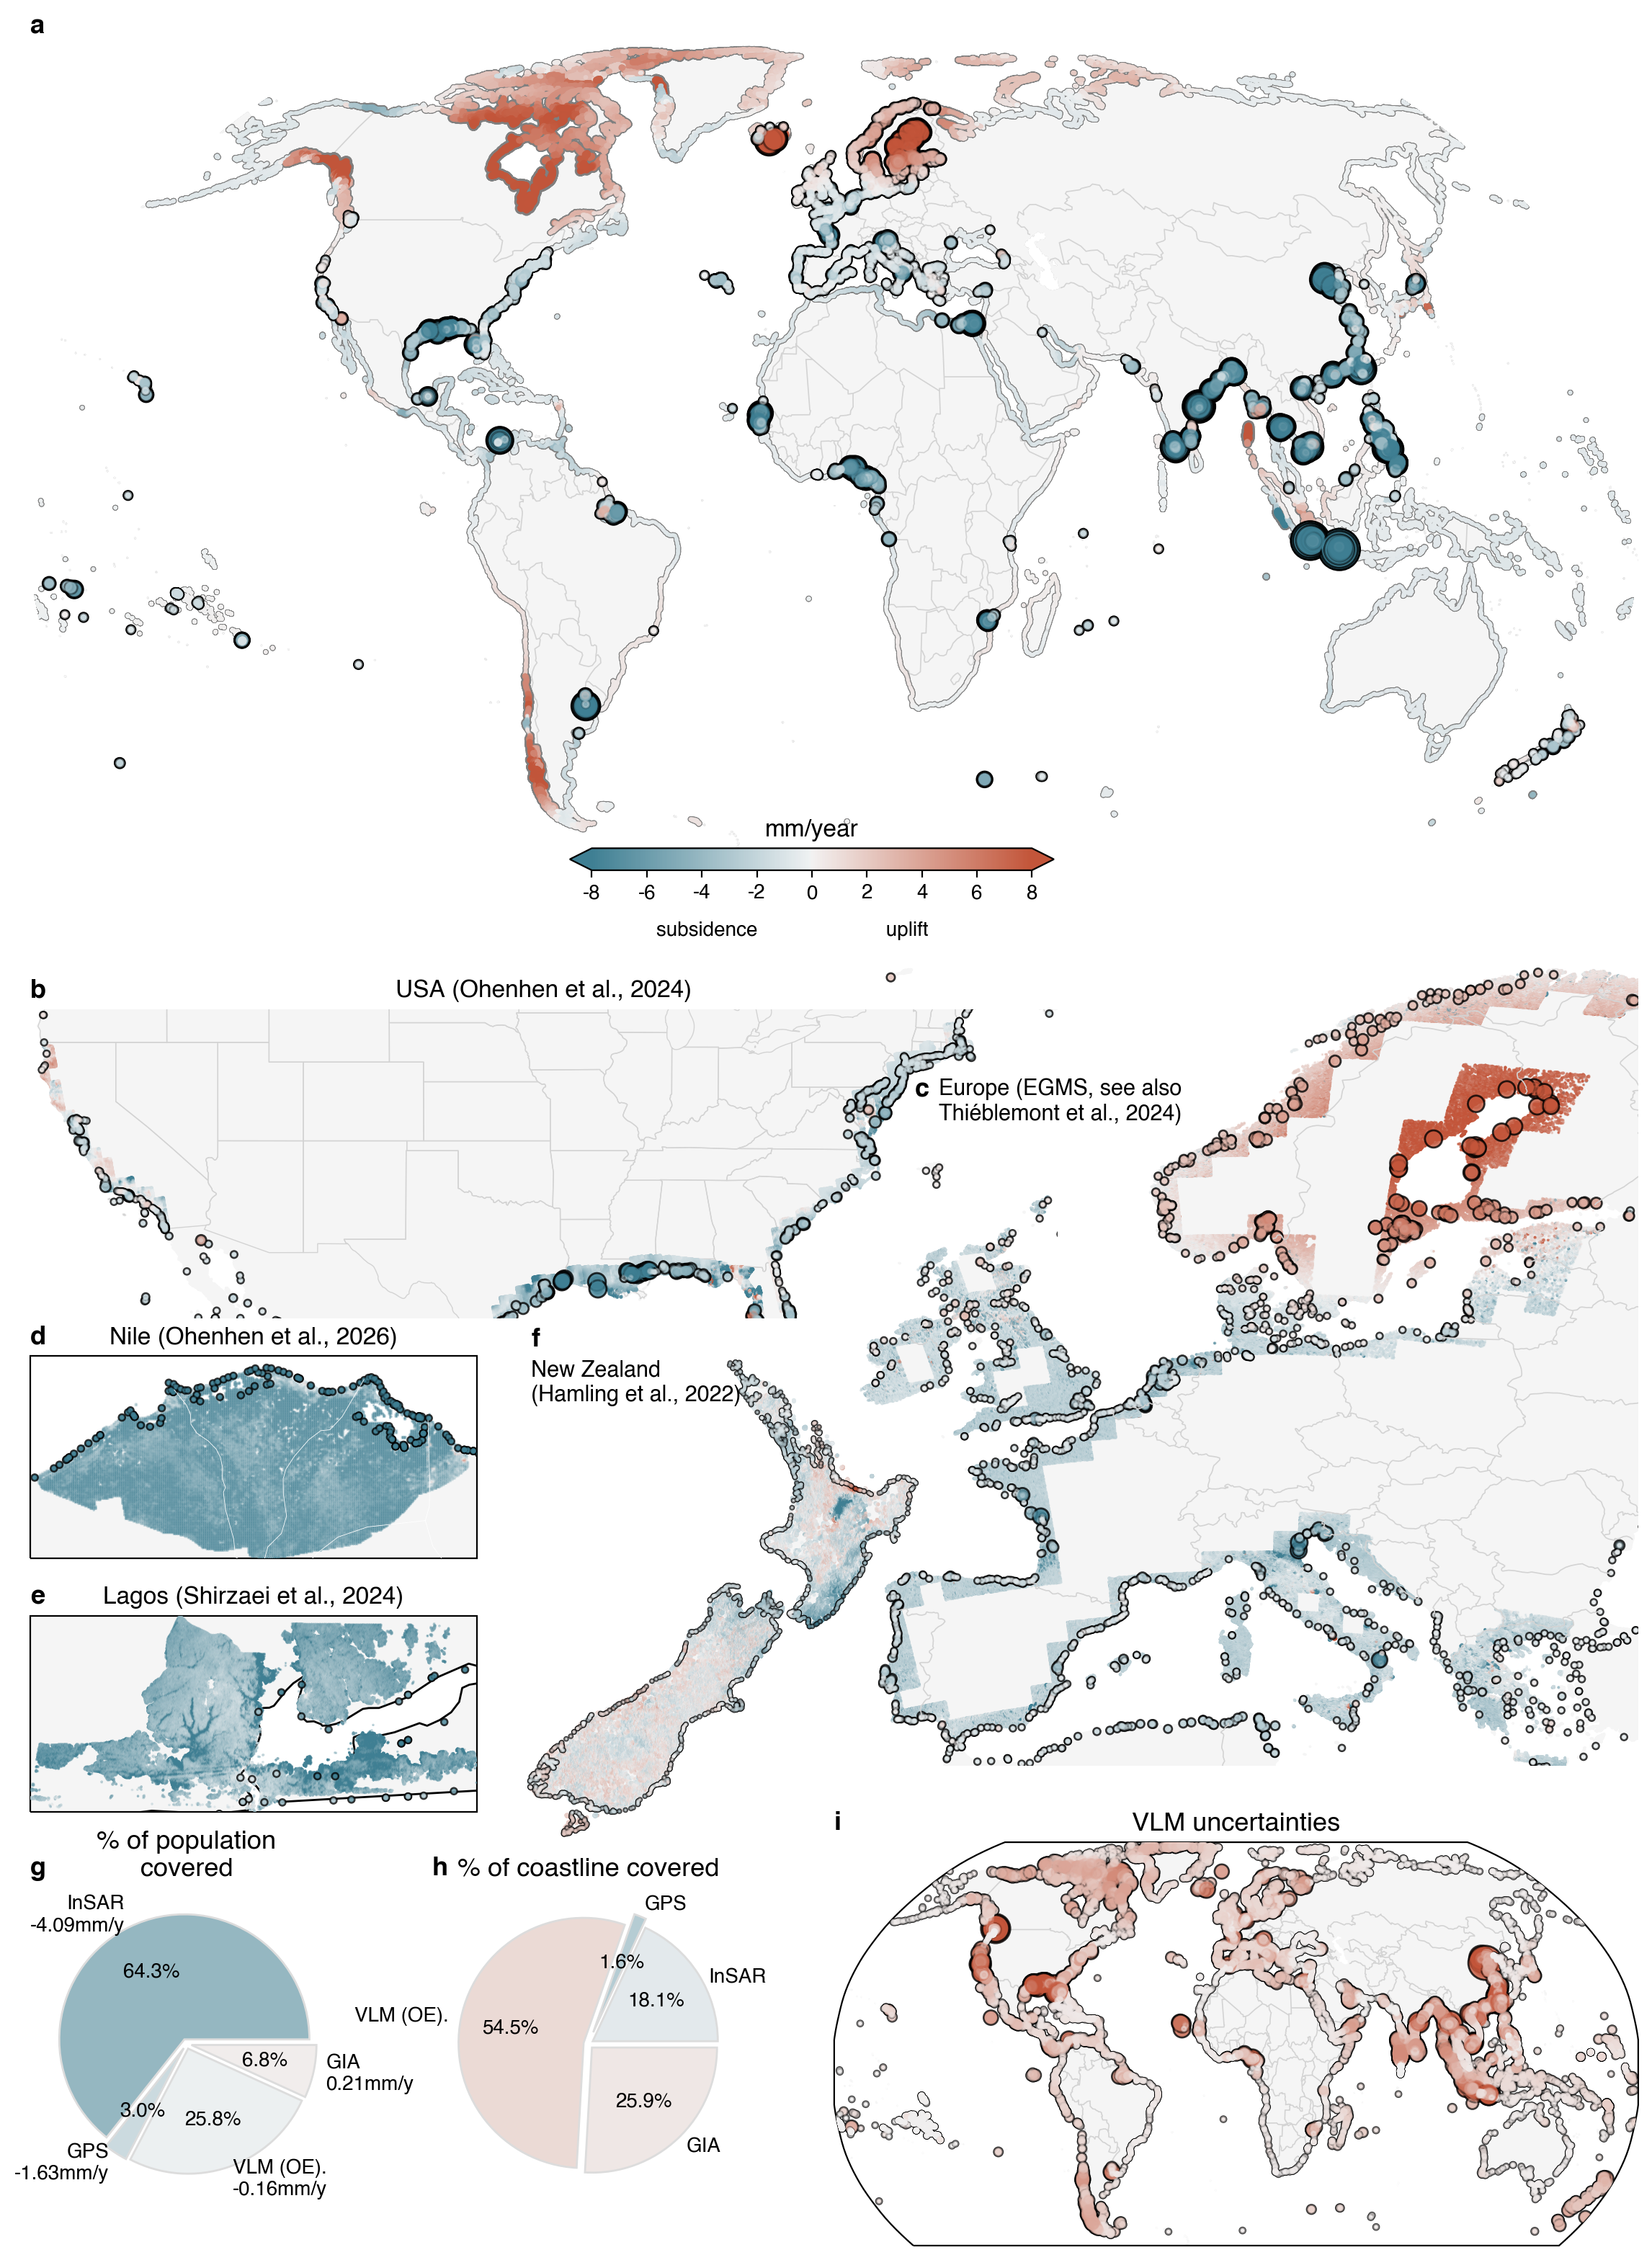

In [39]:

bins= np.linspace(-34,12,(34+12)+1)


proj =ccrs.Robinson(central_longitude=0, globe=None)


fig = plt.figure(figsize=(max_width,max_width*1.4),constrained_layout=True,edgecolor='black')
factor=3
number_of_plots = 4
xp = 1
yp=1
gs = gridspec.GridSpec(22*factor, 12*factor,wspace=0.0, hspace=0.0,top = 1, bottom = 0, right = 0.98, left = 0.05)

long_names = ['InSAR Shirzaei + China','VLM map (EO23)','GIA']
varnames   = ['VLM_InSAR3','VLM_map','GIA']
limits_ = [[-0.008,0.008],[-0.008,0.008],[-8,8]]

units = ['mm/year','mm/year','mm/year']
cbar_extends = ['both','both','both']
# sort_dir = [True,False,].sortby(variable,ascending=False)

ii=0
jj=0


for variable,long_name,limits,unit,cbar_extend,scatter_kws,factorm,scaler_factor,lblbl in zip(varnames,long_names,limits_,units,
                                                                         cbar_extends,[{},{},{},{}],
                                                                        [1000,1000,1],[1,1,1],['A','C','B'][:1]):
    ax = fig.add_subplot(gs[int(ii*16/xp*factor):int((0.7)*16/xp*factor),int(jj*12/yp*factor):int((jj+1)*12/yp*factor)],projection = proj)
    version = 'v2'
    
    size_scatter = 2
    print(variable)

    cmap_err = sns.diverging_palette(220, 20, as_cmap=True)
    print(factorm)
    
    

    variable = 'VLM_map_GIA'
    size_map = 3
    aspect= 1.15
    ax,im = plot_map_ax_mapping(ax,ds['trend_plot'].dropna(dim='x',how='all')*factorm,region='custom',
                                msize=size_map,land_facecolor='lightgrey',aspect=aspect,edgecolor=['grey'],
                scalecolor=True,label='',extend=[-179,179,-60,85],minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                    color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                    glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,msize_frac=0.3,zorder=5,scatter_kws=scatter_kws) 
    
    variable = 'VLM_InSAR6'
    size_map = 20
    ax,im2 = plot_map_ax_mapping(ax,ds_grouped[variable].sel({'x':~np.isnan(ds_grouped['ASL_plus_GIA'])}).dropna(dim='x',how='all')*factorm,region='custom',
                                msize=size_map,land_facecolor='lightgrey',aspect=aspect,edgecolor=['k'],
                scalecolor=True,label='',extend=[-179,179,-60,85],minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=1,alpha_overlay=.4,
                    color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                    glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,scatter_kws=scatter_kws) 
    size_map = 16   
    ax,im = plot_map_ax_mapping(ax,ds_grouped[variable].sel({'x':~np.isnan(ds_grouped['ASL_plus_GIA'])}).dropna(dim='x',how='all')*factorm,region='custom',
                                msize=size_map,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['k'],
                scalecolor=True,label='',extend=[-179,179,-60,85],minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                    color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                    glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,scatter_kws=scatter_kws)

    ax.add_feature(cfeature.BORDERS, linewidth=0.6,color='lightgrey',zorder=1)

    ax.set_rasterization_zorder(10)

ax.axis('off')
    
ax.set_title('a',fontweight='bold',fontsize=main_fontsize,loc='left',zorder=100)

ax = fig.add_subplot(gs[int((0.52)*16/xp*factor):int((0.6)*16/xp*factor),int(0.35*12/yp*factor):int(0.65*12/yp*factor)])


clb =plt.colorbar(im2,ax=ax,extend=cbar_extend,orientation = 'horizontal')
clb.ax.set_title('mm/year',fontsize=labelsize,zorder=100)
ax.set_rasterization_zorder(10)
ax.axis('off')
clb.ax.text(
    -0.3, -45,                # x, y in axis coordinates (centered, below)
    'subsidence                       uplift    ',   # your second label
    ha='center', va='top',
    fontsize=10,zorder=100
)

w2 = 0.25
h2 = 0.7
explode = [0.04] * len(data['labels'])


shift_1 = int(0.32* factor*22)

ax = fig.add_subplot(gs[int((h2)*16/xp*factor)+shift_1:int((1)*16/xp*factor)+shift_1,int(0*12/yp*factor):int((w2-0.03)*12/yp*factor)],projection = proj)


ax.set_title('g',fontweight='bold',fontsize=main_fontsize,loc='left',zorder=100)
ax.set_title('% of population\ncovered',fontsize=main_fontsize,zorder=100)


ax.pie(df['values'], explode = explode, labels=df['labels'], autopct='%1.1f%%',
       colors=[cmap_err(col_/16+0.5) for col_ in [col_2*1000,col_3*1000,col_4*1000,col_5]],textprops={'fontsize': 10},wedgeprops={"edgecolor":'gainsboro','linewidth': 1, 'antialiased': True})

explode = [0.04,0.1,0.04,0.04] 
ax = fig.add_subplot(gs[int(h2*16/xp*factor)+shift_1:int((1)*16/xp*factor)+shift_1,int(w2*12/yp*factor):int((w2*2-0.03)*12/yp*factor)],projection = proj)
ax.set_title('h',fontweight='bold',fontsize=main_fontsize,loc='left',zorder=100)
ax.set_title('% of coastline covered',fontsize=main_fontsize,zorder=100)

ax.pie(df2['values'], explode = explode,labels=df2['labels'], textprops={'fontsize': 10},autopct='%1.1f%%',
       colors=[cmap_err(col_/16+0.5) for col_ in [col_2_l*1000,col_3_l*1000,col_4_l*1000,col_5_l]],wedgeprops={"edgecolor":'gainsboro','linewidth': 1, 'antialiased': True})



ax = fig.add_subplot(gs[int(h2*16/xp*factor)+shift_1:int((1)*16/xp*factor)+shift_1,int(0.5*12/yp*factor):],projection = proj)
variable = 'VLM_map_InSAR6_combined_uncertainty_GIA'


ax,im = plot_map_ax_mapping(ax,ds_grouped[variable].sel({'x':~np.isnan(ds_grouped['ASL_plus_GIA'])}).dropna(dim='x',how='all')[:]*factorm,region='custom',
                            msize=size_map*0.5,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['k'],
            scalecolor=True,label='',extend=[-179,179,-60,85],minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,scatter_kws=scatter_kws) 

ax.add_feature(cfeature.BORDERS, linewidth=0.6,color='lightgrey',zorder=1)

ax.set_title('i',fontweight='bold',fontsize=main_fontsize,loc='left',zorder=100)
ax.set_title('VLM uncertainties',fontsize=main_fontsize,zorder=100)
ax.set_rasterization_zorder(10)
plt.axis('on')

proj =ccrs.PlateCarree(central_longitude=0, globe=None)

usa_extent = [-125, -65, 28, 40]
eur_extent = [-12, 30, 35, 72]
nz_extent  = [165, 180, -48, -33]

variable = 'VLM_map_InSAR6_GIA'
size_map = 10
size_insar = 0.2

shift_2=int(-0.18*factor*22)

ax = fig.add_subplot(gs[int((0.8)*16/xp*factor)+shift_2:int((0.85)*22/xp*factor)+shift_2,int(0.*12/yp*factor):int(0.65*12/yp*factor)],projection = proj)



ax,im = plot_map_ax_mapping(ax,data_usa['VLM'][::500],region='custom',
                            msize=size_insar,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['None'],
            scalecolor=True,label='',extend=usa_extent,minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,msize_frac=0.3,scatter_kws=scatter_kws) 


ax,im = plot_map_ax_mapping(ax,ds_grouped[variable].dropna(dim='x',how='all')*factorm,region='custom',
                            msize=size_map,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['k'],
            scalecolor=True,label='',extend=usa_extent,minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,msize_frac=0.3,scatter_kws=scatter_kws) 
ax.axis('off')
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='lightgrey',zorder=4)
ax.set_rasterization_zorder(10)
ax.set_title('b',fontweight='bold',fontsize=main_fontsize,loc='left',zorder=100)
ax.set_title('USA (Ohenhen et al., 2024)',zorder=100)

# EU

ax = fig.add_subplot(gs[int((0.8)*16/xp*factor)+shift_2:int((1)*22/xp*factor)+shift_2,int(0.5*12/yp*factor):],projection = proj)


ax,im = plot_map_ax_mapping(ax,data_egms_t.dropna(dim='x',how='all')[::50],region='custom',
                            msize=size_insar ,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['None'],
            scalecolor=True,label='',extend=eur_extent,minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,msize_frac=0.3,scatter_kws=scatter_kws) 

ax,im = plot_map_ax_mapping(ax,ds_grouped[variable].dropna(dim='x',how='all')*factorm,region='custom',
                            msize=size_map,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['k'],
            scalecolor=True,label='',extend=eur_extent,minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,msize_frac=0.3,scatter_kws=scatter_kws) 

ax.add_feature(cfeature.BORDERS, linewidth=0.6,color='lightgrey',zorder=6)

ax.text(0.1,0.8, "c",fontsize=main_fontsize,fontweight='bold',transform=ax.transAxes,zorder=100)
ax.text(0.13,0.771, "Europe (EGMS, see also\nThiéblemont et al., 2024)",fontsize=11,transform=ax.transAxes,zorder=100)
ax.set_rasterization_zorder(10)
ax.axis('off')


# New Zealand
ax = fig.add_subplot(gs[int((0.78)*22/xp*factor)+shift_2:int((1)*22/xp*factor)+shift_2,int(0.3*12/yp*factor):int(0.6*12/yp*factor)],projection = proj)


ax,im = plot_map_ax_mapping(ax,dsn['trend'][::3],region='custom',
                            msize=size_insar*15,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['None'],
            scalecolor=False,label='',extend=nz_extent,minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,msize_frac=0.3,scatter_kws=scatter_kws) 

ax,im = plot_map_ax_mapping(ax,data_nz['VLM'][:],region='custom',
                            msize=size_insar*15,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['None'],
            scalecolor=False,label='',extend=nz_extent,minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,msize_frac=0.3,scatter_kws=scatter_kws) 

ax,im = plot_map_ax_mapping(ax,InSAR_NZ['trend'][:]*1000.,region='custom',
                            msize=size_insar*15,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['k'],
            scalecolor=False,label='',extend=nz_extent,minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,msize_frac=0.3,scatter_kws=scatter_kws) 



ax.add_feature(cfeature.BORDERS, linewidth=0.6,color='lightgrey',zorder=12)
ax.set_rasterization_zorder(10)
ax.axis('off')



ax.text(0.1,0.935, "f",fontsize=main_fontsize,fontweight='bold',transform=ax.transAxes,zorder=100)
ax.text(0.1,0.835, "New Zealand\n(Hamling et al., 2022)",fontsize=11,transform=ax.transAxes,zorder=100)

# Nile
ax = fig.add_subplot(gs[int((0.68)*22/xp*factor)+shift_2:int((1)*22/xp*factor)+shift_2,int(0.*12/yp*factor):int(0.3*12/yp*factor)],projection = proj)
extend = [ds_t['trend'].lon.min(),ds_t['trend'].lon.max(),ds_t['trend'].lat.min()+0.3,ds_t['trend'].lat.max()]

ax,im = plot_map_ax_mapping(ax,ds_t['trend'][:],region='custom',
                            msize=size_insar,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['None'],
            scalecolor=False,label='',extend=nz_extent,minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,msize_frac=0.3,scatter_kws=scatter_kws) 

ax,im = plot_map_ax_mapping(ax,Ohenhen25_delta['trend'].dropna(dim='x',how='all')*factorm,region='custom',
                            msize=size_map,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['k'],
            scalecolor=False,label='',extend=extend,minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,zorder=5,msize_frac=0.3,scatter_kws=scatter_kws) 

ax.add_feature(
    cfeature.RIVERS.with_scale('50m'),
    linewidth=0.3,
    edgecolor='white',
    zorder=50
)



ax.set_title('d',fontweight='bold',fontsize=main_fontsize,loc='left',zorder=100)
ax.set_title('Nile (Ohenhen et al., 2026)',zorder=100)

ax.add_feature(cfeature.BORDERS, linewidth=0.6,color='white')
ax.set_rasterization_zorder(10)
ss = ax.get_subplotspec()

row0, row1 = ss.rowspan.start, ss.rowspan.stop
col0, col1 = ss.colspan.start, ss.colspan.stop


# Cities
k = 0

for city in All_Data_nc[10:11]:
    ax = fig.add_subplot(gs[int((0.89)*22/xp*factor)+shift_2:int((1)*22/xp*factor)+shift_2,col0:col1],projection = proj)

    extend = [city['VLM'].lon.min(),city['VLM'].lon.max(),city['VLM'].lat.min(),city['VLM'].lat.max()]
    ax,im = plot_map_ax_mapping(ax,city['VLM'][:],region='custom',
                                msize=size_insar,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['None'],
                scalecolor=False,label='',extend=nz_extent,minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                    color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                    glbottom=True,glright=False,overlay_ocean=True,draw_gridlines=False,zorder=5,msize_frac=0.3,scatter_kws=scatter_kws) 

    ax,im = plot_map_ax_mapping(ax,InSAR_cities['trend'].dropna(dim='x',how='all')*factorm,region='custom',
                                msize=size_map,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['k'],
                scalecolor=False,label='',extend=extend,minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.8,alpha_overlay=.4,
                    color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,zorder=5,
                    glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,msize_frac=0.3,scatter_kws=scatter_kws) 

    ax.coastlines(resolution='10m',color='grey',linewidth=0.5)
    ax.set_rasterization_zorder(10)
    k=k+1

ax.set_title('e',fontweight='bold',fontsize=main_fontsize,loc='left',zorder=100)
ax.set_title('Lagos (Shirzaei et al., 2024)',zorder=100)

plt.savefig(settings['plot_main'] + 'Figure_1.png',bbox_inches='tight')
plt.savefig(settings['plot_main'] + 'Figure_1.pdf',bbox_inches='tight')

plt.show()

# Figure 2

In [40]:

data = pd.read_csv(settings['data_in']+'Nicholls2021/41558_2021_993_MOESM6_ESM.csv',sep=',')
data3 = pd.read_csv(settings['data_in']+'Nicholls2021/41558_2021_993_MOESM2_ESM.csv',sep=',')

variables = data['variable'].drop_duplicates().values
data1 = data[data['variable'] == '(e) All SLR components combined'].sort_values('locationid')

mask = (data3['variable'] == 'Population-weighted coastal relative sea level') & (data3['subsidence'] =='lower estimate')
mask2 = (data3['variable'] == 'Population-weighted coastal relative sea level') & (data3['subsidence'] =='upper estimate')


mask21 = (data3['variable'] == 'Length-weighted coastal relative sea level') & (data3['subsidence'] =='lower estimate')
mask22 = (data3['variable'] == 'Length-weighted coastal relative sea level') & (data3['subsidence'] =='upper estimate')


# Add lower VLM estimate to ds_group
# Add lower city only estimate to ds_group

data_comb = copy.deepcopy(data3[mask])
data_comb=data_comb.sort_values('locationid')
data_comb=data_comb[np.isin(data_comb['locationid'],data1['locationid'].values)]

data_comb2 = copy.deepcopy(data3[mask2])
data_comb2=data_comb2.sort_values('locationid')
data_comb2=data_comb2[np.isin(data_comb2['locationid'],data1['locationid'].values)]

data_comb['rslr_upper'] = data_comb2['rslr'].values
data_comb['diff'] = data_comb['rslr_upper'] - data_comb['rslr'] # this has to be subtracted from the city, or total VLM estimate


ds_grouped['delta_low'] = copy.deepcopy(ds_grouped['test_val'])*np.nan
ds_grouped['delta_low'][np.isin(ds_grouped.name,data_comb['locationid'])] = data_comb['diff'].values
ds_grouped['Nicholls_subsidence'] = (ds_grouped['e All SLR components combined']-ds_grouped['a Climate-induced SLR only'])*-1
ds_grouped['Nicholls_subsidence_lower'] = ds_grouped['Nicholls_subsidence']+ds_grouped['delta_low']/1000.
ds_grouped['Nicholls_subsidence_avg'] = (ds_grouped['Nicholls_subsidence']+ds_grouped['Nicholls_subsidence_lower'])/2
ds_grouped['delta_low'] = copy.deepcopy(ds_grouped['test_val'])*np.nan
ds_grouped['delta_low'][np.isin(ds_grouped.name,data_comb['locationid'])] = data_comb['diff'].values

sorted_set = ds_grouped.sortby('VLM_map_InSAR'+ settings['Version']+'_GIA')
ds_grouped['VLM_map_GIA'] = copy.deepcopy(ds_grouped['VLM_map'])
ds_grouped['VLM_map_GIA'][np.isnan(ds_grouped['VLM_map'])] = ds_grouped['GIA'][np.isnan(ds_grouped['VLM_map'])]/1000.

cusum_out = 100*np.cumsum(sorted_set['pop_below_10p0'])/np.sum(ds_grouped['pop_below_10p0'])
cusum_out_norm = np.cumsum(sorted_set['pop_below_10p0'])#/np.sum(ds_grouped['pop_below_10p0'])
frac_prev = []
for val in [-1,-2,-3]:
    frac_prev.append(float(ds_grouped['pop_below_10p0'][ds_grouped['VLM_map_GIA']<val/1000.].sum()/np.sum(ds_grouped['pop_below_10p0'])))


names_country = [name[:7] for name in ds_grouped.name.values]
ds_grouped['names_country'] = copy.deepcopy(ds_grouped['name'])
ds_grouped['names_country'][:]=names_country
ds_grouped_sum = ds_grouped.groupby('names_country').sum()
ds_grouped['RSL_VLM_map_InSAR9_GIA_weighted'] = ds_grouped['RSL_VLM_map_InSAR'+ settings['Version']+'_GIA']*ds_grouped['pop_below_10p0']
ds_grouped_mean = ds_grouped.groupby('names_country').sum()
test_out = ds_grouped[['RSL_VLM_map_InSAR'+ settings['Version']+'_GIA','names_country','pop_below_10p0']].groupby('names_country').apply(lambda x: np.sum(x['RSL_VLM_map_InSAR'+ settings['Version']+'_GIA']*x['pop_below_10p0'])/np.sum(x['pop_below_10p0']) if len(x) >0 else 0)*1000.
sum_pop_p_country = ds_grouped[['RSL_VLM_map_InSAR'+ settings['Version']+'_GIA','names_country','pop_below_10p0']].groupby('names_country').apply(lambda x: np.sum(x['pop_below_10p0']) if len(x) >0 else 0)

# Get countries
resolution = '10m'
category = 'cultural'
name = 'admin_0_countries'
shpfilename = shapereader.natural_earth(resolution, category, name)

# read the shapefile using geopandas
df_c = geopandas.read_file(shpfilename)

In [263]:
def bootstrap_cdf(ds_grouped,ERROR,name = 'VLM_map', iterations = 5000, thresholds =[0,1,2]):

    """
    
    """
    res =1000 # percentile resolution
    rng = np.random.default_rng()
    CDFmat = np.empty([res,iterations])*0
    targets = np.arange(res)/(res)

    distr = []
    thresh_out = []
    for i in range(iterations)[:]:
        resh_VLM = rng.normal(loc=0.0, scale=ERROR)*1
        idx = np.argsort((ds_grouped[name]+resh_VLM)*-1)
        sorted_set = ds_grouped[[name,'pop_below_10p0']].isel(x=idx) 
        t_sub =[]
        perturbed_VLM = (sorted_set[name]+resh_VLM[idx])*-1000.
        # print(np.min(perturbed_VLM),np.max(sorted_set[name]))
        for t in thresholds:
            t_sub.append(float(np.sum(sorted_set['pop_below_10p0'][perturbed_VLM>t])))
        cdf_weighted_people = np.cumsum(sorted_set['pop_below_10p0']) / np.sum(sorted_set['pop_below_10p0'])
        idx2 = np.abs(cdf_weighted_people.values[:, None] - targets[None, :]).argmin(axis=0)
        CDFmat[:,i]=perturbed_VLM.values[idx2]
        thresh_out.append(t_sub)
    return thresh_out,CDFmat,targets

thresh_out,CDFmat,targets = bootstrap_cdf(ds_grouped,ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'],name = 'VLM_map_InSAR'+ settings['Version']+'_GIA', iterations = 1000, thresholds =[0,1,2])

## Estimate smooth population grid

In [ ]:


R = 6371.0  # Earth radius in km

def arc_to_chord_km(arc_km, R=6371.0):
    return 2 * R * np.sin(arc_km / (2 * R))

# -----------------------------
# 1. Prepare coastal data
# -----------------------------
lon = ds_grouped['pop_below_10p0_nonzero'].lon.values
lat = ds_grouped['pop_below_10p0_nonzero'].lat.values
y = ds_grouped['pop_below_10p0_nonzero'].values.flatten()

X = np.column_stack([lon, lat])

valid_mask = ~np.isnan(y)
X = X[valid_mask]
y = y[valid_mask]

# xyz coordinates on sphere, in km
X_km = lonlat_to_xyz_km(X[:, 0], X[:, 1])

# -----------------------------
# 2. Prediction grid
# -----------------------------
lon_new = np.linspace(lon.min(), lon.max(), 550)
lat_new = np.linspace(lat.min(), lat.max(), 550)

lon_grid, lat_grid = np.meshgrid(lon_new, lat_new)
X_pred = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])
X_pred_km = lonlat_to_xyz_km(X_pred[:, 0], X_pred[:, 1])

# -----------------------------
# 3. Surface distances in km -> chord distances in xyz km
# -----------------------------
search_radius_arc = 700.0
length_scale_arc = 125.0

search_radius = arc_to_chord_km(search_radius_arc, R)
length_scale = arc_to_chord_km(length_scale_arc, R)

# -----------------------------
# 4. Local RBF smoother
# -----------------------------
tree = cKDTree(X_km)

y_pred_full = np.zeros(X_pred.shape[0], dtype=float)
sigma_full = np.zeros(X_pred.shape[0], dtype=float)

for i, p in enumerate(X_pred_km):
    nbr_idx = tree.query_ball_point(p, r=search_radius)
    if not nbr_idx:
        continue

    Xnbr = X_km[nbr_idx]
    ynbr = y[nbr_idx]

    # chord distances in xyz space
    d = np.linalg.norm(Xnbr - p, axis=1)

    w = np.exp(-(d**2) / (2 * length_scale**2))
    mu = np.dot(w, ynbr)
    y_pred_full[i] = mu


y_pred = y_pred_full.reshape(len(lat_new), len(lon_new))
sigma = sigma_full.reshape(len(lat_new), len(lon_new))

ds_rbf = xr.Dataset(
    data_vars={
        "prediction": (["lat", "lon"], y_pred),
        "uncertainty": (["lat", "lon"], sigma),
    },
    coords={
        "lat": lat_new,
        "lon": lon_new,
    }
)

71%, 545 (501-584) million 
55%, 426 (378-469) million 
43%, 337 (289-384) million 
United Kingdom <xarray.DataArray ()>
array(0.44277488)
Coordinates:
    names_country  <U7 'CLS_GBR'


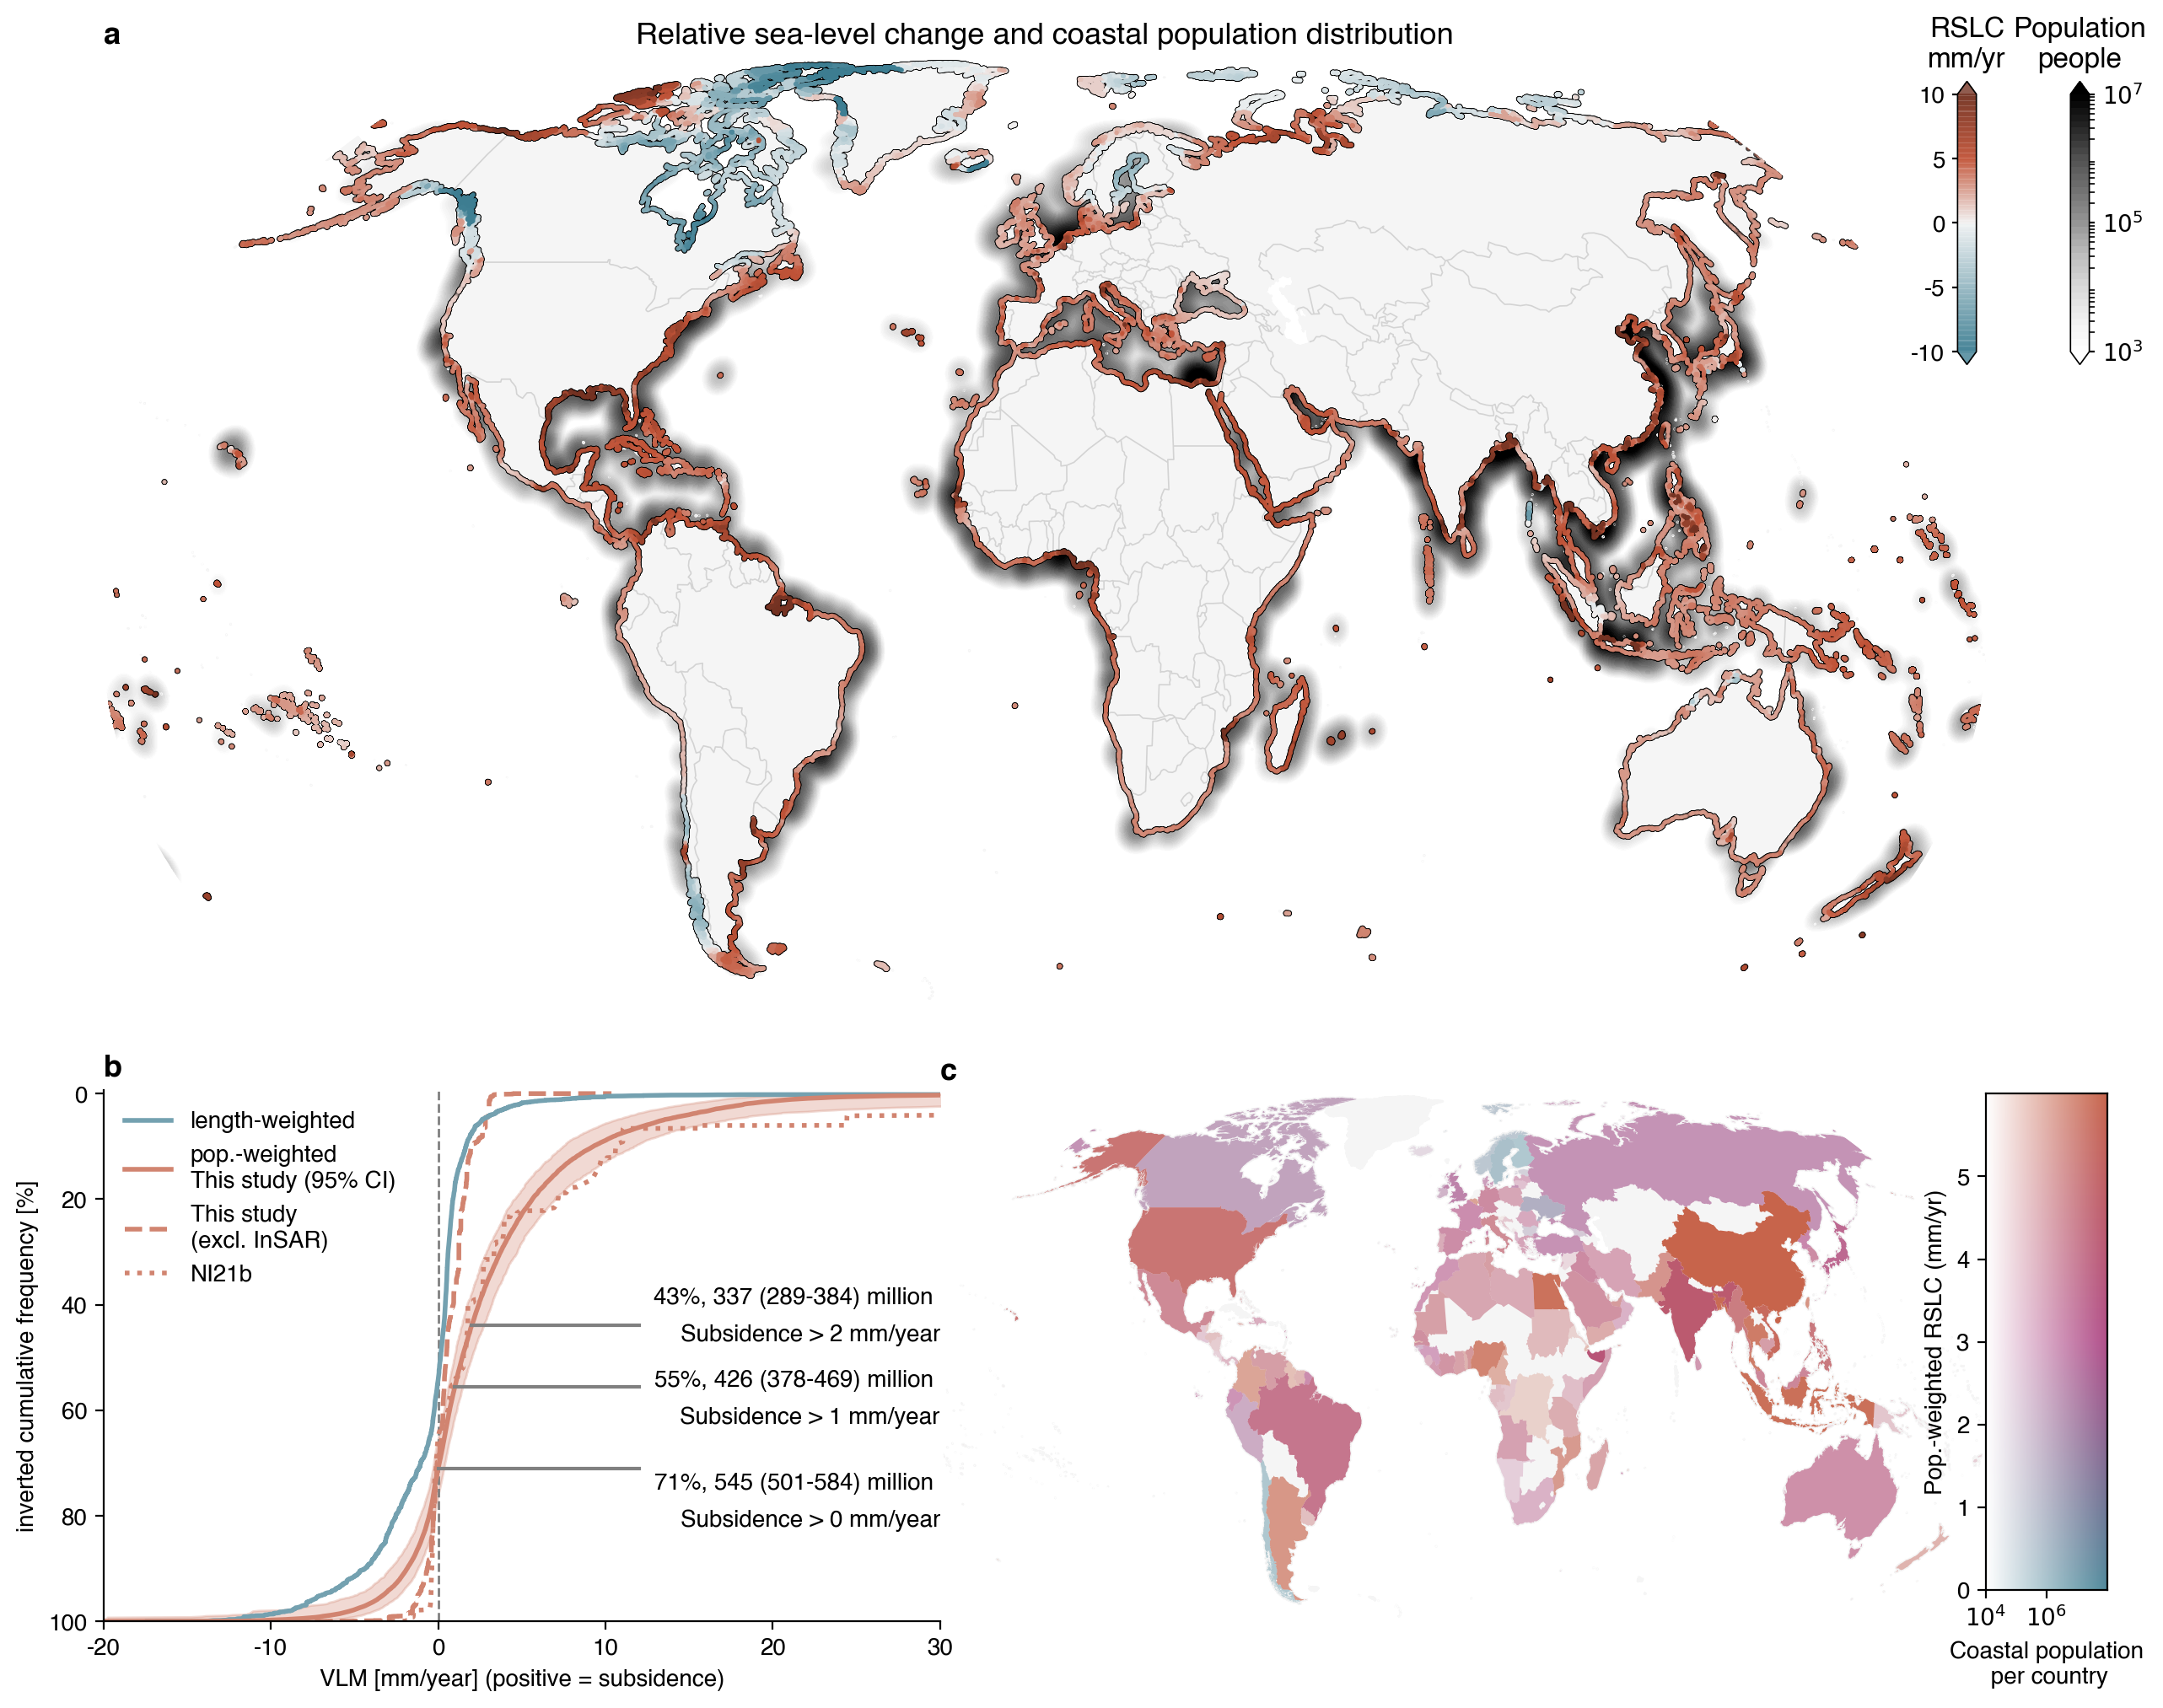

In [50]:

# -------------------------------------------------
# Prepare data
# -------------------------------------------------
ds_grouped['pop_below_10p0_nonzero'] = copy.deepcopy(ds_grouped['pop_below_10p0'])
ds_grouped['pop_below_10p0_nonzero'][ds_grouped['pop_below_10p0'] < 10] = 1

proj = ccrs.Robinson()

fig = plt.figure(figsize=(max_width, max_width*1.4), constrained_layout=True)
factor = 3
xp = 2.5
yp = 2
gs = gridspec.GridSpec(
    16 * factor, 12 * factor,
    wspace=0.0, hspace=0.0,top = 1, bottom = 0, right = 0.98, left = 0.05)

# -------------------------------------------------
# Metadata
# -------------------------------------------------
long_names = ['RSLC', 'Population below 10m']
varnames = ['RSL_VLM_map_InSar_GIA', 'pop_below_10p0_nonzero']
limits_ = [[-0.01, 0.01], [10**1, 10**8]]
units = ['mm/year', 'people']
cbar_extends = ['both', 'max']

use_exp_index = False

# -------------------------------------------------
# Main axis
# -------------------------------------------------
ax = fig.add_subplot(
    gs[int(0 * 16 / xp * factor):int((0 + 1.2) * 16 / xp * factor), 0:],
    projection=proj
)

version = 'v2'
size_map = 2
size_scatter = 2


# -------------------------------------------------
# Plot 1: RSL
# -------------------------------------------------


variable = 'RSL_VLM_map_InSar_GIA'
long_name = 'Relative sea-level change and coastal population distribution'
limits = [-0.01, 0.01]
unit = 'mm/year'
cbar_extend = 'both'
scatter_kws = {}
factorm = 1000
scaler_factor = 1
lblbl = 'a'
data = ds['trend_plot_RSL'].sortby(abs(ds['trend_plot_RSL']), ascending=True)[:]
order = 6

cmap_err = sns.diverging_palette(220, 20, as_cmap=True)

ax, im1 = plot_map_ax_mapping(
    ax,
    data.dropna(dim='x', how='all')[:] * factorm,
    region='custom',
    msize_frac=0.3,
    msize=size_map,
    land_facecolor='whitesmoke',
    aspect=aspect,
    edgecolor=['k'],
    scalecolor=False,
    label='',
    extend=[-179, 179, -60, 85],
    minv=limits[0] * abs(factorm),
    maxv=limits[1] * abs(factorm),
    alpha=0.8,
    alpha_overlay=.4,
    color_map=cmap_mod,
    gltop=False,
    glleft=False,
    scaler_factor=scaler_factor,
    zorder=order,
    glbottom=True,
    glright=False,
    overlay_ocean=False,
    draw_gridlines=False,
    scatter_kws=scatter_kws
)

ax.set_rasterization_zorder(10)
ax.set_title(lblbl, loc='left', fontsize=main_fontsize, fontweight="bold",zorder=100)
ax.set_title(long_name, loc='center', fontsize=main_fontsize,zorder=100)

# -------------------------------------------------
# Plot 2: Population overlay from ds_rbf
# -------------------------------------------------
Z = ds_rbf["prediction"].values
lon = ds_rbf["lon"].values
lat = ds_rbf["lat"].values

# LogNorm cannot handle <= 0
Z_plot = np.where(Z > 0, Z, np.nan)
levels = np.logspace(3, 7, 40)

cf = ax.contourf(
    lon,
    lat,
    Z_plot,
    levels=levels,
    transform=ccrs.PlateCarree(),
    cmap="Greys",
    norm=colors.LogNorm(vmin=1e3, vmax=1e7),
    extend="both",zorder=1
)



# -------------------------------------------------
# Features on top
# -------------------------------------------------
land_50m = cfeature.NaturalEarthFeature(
    'physical', 'land', '10m',
    edgecolor='face',
    facecolor='whitesmoke'
)
ax.add_feature(land_50m, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.6, color='lightgrey', zorder=5)

ax.axis('off')

# -------------------------------------------------
# Two inset colorbars inside the same axis
# upper-right corner, next to each other
# -------------------------------------------------
cax_rsl = inset_axes(
    ax,
    width="1%",
    height="30%",
    loc="upper right",
    bbox_to_anchor=(-0.0, -0.015, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0.4
)

cax_pop = inset_axes(
    ax,
    width="1%",
    height="30%",
    loc="upper right",
    bbox_to_anchor=(0.06, -0.015, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0.4
)

# RSL colorbar
clb_rsl = plt.colorbar(im1, cax=cax_rsl, extend='both')
clb_rsl.ax.set_title('RSLC\nmm/yr',  pad=6,zorder=100)
clb_rsl.ax.tick_params(length=2)
clb_rsl.ax.yaxis.set_ticks_position('left')
clb_rsl.outline.set_linewidth(0.6)

# Population colorbar
clb_pop = plt.colorbar(cf, cax=cax_pop, extend='both')
clb_pop.ax.set_title('Population\npeople',  pad=6,zorder=100)
clb_pop.ax.tick_params(length=2)
clb_pop.set_ticks([1e3, 1e5, 1e7])
clb_pop.set_ticklabels([r'$10^3$', r'$10^5$', r'$10^7$'])
clb_pop.outline.set_linewidth(0.6)




    
pallete = sns.color_palette("Set2")

mask = ds_grouped['VLM_map_InSAR'+ settings['Version']+'_GIA']< - 0.002

jj = 0
ax = fig.add_subplot(gs[int(1.13*16/xp*factor):int(1.6*16/xp*factor),int(0.05*12/yp*factor):int((jj+0.94)*12/yp*factor)])


ax.set_title("b",fontweight='bold',loc='left',fontsize=main_fontsize)
ax.axvline(0, color='grey', linestyle='--', lw=1)



sign=-1
for var,names,kwargs in zip(['VLM_map_GIA','Nicholls_subsidence_avg','VLM_map_InSAR'+ settings['Version']+'_GIA'],
                            ['This study\n(excl. InSAR)','NI21b','This study'],
                            [{'linestyle':'--'},{'linestyle':':'},{}]):

    sorted_set_sub = ds_grouped[[var,'pop_below_10p0','length']].sortby(ds_grouped[var]*sign)
    # Unweighted CDF
    data = ds_grouped[var]*sign
    data_sorted = sorted_set_sub[var]
    cdf_unweighted = np.arange(1, len(data_sorted)+1) / len(data_sorted)

    # Weighted CDF
    sorted_idx = np.argsort(data)
    data_sorted_w = data[sorted_idx]*1000.

    weights_people = sorted_set_sub['pop_below_10p0']
    weights_length = sorted_set_sub['length']

    cdf_weighted_people = np.cumsum(weights_people) / np.sum(weights_people)
    cdf_weighted_length = np.cumsum(weights_length) / np.sum(weights_length)

    # Plot
    if var == 'VLM_map_InSAR'+ settings['Version']+'_GIA':
        ax.plot(data_sorted_w, cdf_weighted_length*100, label="length-weighted", lw=2,color = cmap_err(0.15))
        low  = np.percentile(CDFmat, 2.5, axis=1)
        high = np.percentile(CDFmat, 97.5, axis=1)
        ax.fill_betweenx(targets*100, low, high, alpha=0.3,color = cmap_err(0.85))
        
    if 'This study' == names:
        label = "pop.-weighted"+'\n'+names +' (95% CI)'
    else:
        label = names

    if var == 'VLM_map_InSAR'+ settings['Version']+'_GIA':
        ax.plot(np.percentile(CDFmat, 50, axis=1),targets*100, label=label, lw=2,color = cmap_err(0.85),**kwargs)
    else:
        ax.plot(data_sorted_w, cdf_weighted_people*100, label=label, lw=2,color = cmap_err(0.85),**kwargs)        

ax.set_xlabel("VLM [mm/year] (positive = subsidence)")
yticks = ax.get_yticks()
ax.set_yticklabels((100 - yticks-20).astype(int))
ax.set_ylabel("inverted cumulative frequency [%]")

handles, labels = ax.get_legend_handles_labels()

# Create legend using only the first one
ax.legend(handles[-2:]+handles[:2], labels[-2:]+labels[:2], loc="upper left",frameon=False)

ax.set_xlim([-20,30])
ax.set_ylim(0,1.006*100)
#ax.grid(True)

values_perc = [0.4,0.6,0.8]


y_pos = np.array([1,2,3])[::-1]*0.5+1.65
# Draw boxes with text
Median_pop = (np.median(np.array(thresh_out),axis=0))
CIsu = (np.percentile(np.array(thresh_out),97.5,axis=0))
CIsl = (np.percentile(np.array(thresh_out),2.5,axis=0))

for i in range(3):
    
    vperc = Median_pop[i]/sorted_set_sub['pop_below_10p0'].sum().values
    medp = Median_pop[i]
    text = str(int(vperc*100)) +  '%, '+str(int(np.round(medp/1000000,1)))+' ('+str(int(np.round(CIsl[i]/1000000)))+'-'+str(int(np.round(CIsu[i]/1000000)))+')'+' million '
    print(text)
    
    text2 = 'Subsidence > ' + str(i) + ' mm/year'

    ax.text(30,(1-vperc)*100+(i-1)*4,text,ha='right',fontsize=10)
    ax.text(30,(1-vperc)*100-7+(i-1)*4,text2,ha='right',fontsize=10)

    ax.plot([np.percentile(CDFmat, 50, axis=1)[np.argmin(abs(targets*100-((1-vperc)*100)))],12],[(1-vperc)*100,(1-vperc)*100],color='grey')

sns.despine()



ax = fig.add_subplot(gs[int(0.7*16/xp*factor):int((2)*16/xp*factor),int(0.9*12/yp*factor):int((1+1)*12/yp*factor)],projection = proj)
ax,im = plot_map_ax_mapping(ax,data.dropna(dim='x',how='all')[:2]*0,region='custom',
                            msize=0.1,land_facecolor='whitesmoke',aspect=aspect,edgecolor=None,
            scalecolor=True,label='',extend=[-179,179,-60,85],minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.,alpha_overlay=0,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False) 


cmap = cmap_no_white  #matplotlib.cm.get_cmap('viridis')


log_scale =copy.deepcopy(test_out)
lags = [0,6]

log_scale[log_scale>6]=6
log_scale[log_scale<0]=0

# 1. take the log (add small epsilon to avoid log(0))
log_vals = np.log10(sum_pop_p_country.fillna(0) + 1e-12)


n_val  = 256               # vertical resolution of the bar
n_pop  = 256               # horizontal resolution of the bar


pop_norm = np.arange(n_pop)/n_pop
vals_norm = np.arange(n_pop)/n_pop

# --- build RGBA image -------------------------------------------
img = np.zeros((n_val, n_pop, 4))

for i, vn in enumerate(vals_norm):
    # get base color for this data value (same for all columns)
    r, g, b, _ = cmap_val(vn)
    img[i, :, 0] = r
    img[i, :, 1] = g
    img[i, :, 2] = b
    # alpha varies along x (population)
    img[i, :, 3] = pop_norm


pop_min = 4
pop_max = 8

# 2. normalize to [0, 1]
alpha = (log_vals - pop_min) / (pop_max - pop_min)

alpha[alpha<0]=0
alpha[alpha>0.9999999]=0.999999

count_names= []
for country, lag_norm,al in zip([name[-3:] for name in ds_grouped_sum['names_country'].values[:]], log_scale/np.nanmax(log_scale),alpha.values):
    # read the borders of the country in this loop

    c = cmap(lag_norm)
    r, g, b, _ = c
    rgba = (r, g, b, al)


    if country in df_c['SOV_A3'].values:
        #print(country)
        poly = df_c.loc[df_c['SOV_A3'] == country]['geometry'].values[0]
        if poly.geom_type=='Polygon': 
            poly=[poly]

        count_names.append(df_c.loc[df_c['SOV_A3'] == country]['SOVEREIGNT'].values[0])

        ax.add_geometries(poly, crs=ccrs.PlateCarree(), facecolor=rgba, edgecolor='none', zorder=1)
    else:
        if country=='CHN':
            country = 'CH1'
        if country=='FIN':
            country = 'FI1'
        elif country=='DNK':
            country = 'DN1'
        elif country=='AUS':
            country = 'AU1'   
        elif country=='CUB':
            country = 'CU1'   
        elif country=='USA':
            country = 'US1'  
        elif country=='NZL':
            country = 'NZ1' 
        elif country=='FRA':
            country = 'FR1' 
            
        if country in df_c['SOV_A3'].values:
            #print(country)
            poly = df_c.loc[df_c['SOV_A3'] == country]['geometry'].values[0]
            if poly.geom_type=='Polygon': 
                poly=[poly]

            count_names.append(df_c.loc[df_c['SOV_A3'] == country]['SOVEREIGNT'].values[0])
            # plot the country on a map
            ax.add_geometries(poly, crs=ccrs.PlateCarree(), facecolor=rgba, edgecolor='none', zorder=1)
            
        elif country=='GBR':
            country = 'United Kingdom'
            if country in df_c['ADMIN'].values:
                #print(country)
                poly = df_c.loc[df_c['ADMIN'] == 'United Kingdom']['geometry'].values[0]
                if poly.geom_type=='Polygon': 
                    poly=[poly]

                count_names.append(df_c.loc[df_c['ADMIN'] == 'United Kingdom']['SOVEREIGNT'].values[0])
                # plot the country on a map
                print(country,lag_norm)
                ax.add_geometries(poly, crs=ccrs.PlateCarree(), facecolor=rgba, edgecolor='none', zorder=2)
        elif country=='FI1':
            country = 'Finland'

            poly = df_c[df['SOV_A3'] == 'FI1'].geometry.iloc[0]
            count_names.append(df_c.loc[df_c['SOV_A3'] == 'FI1']['SOVEREIGNT'].values[0])

            ax.add_geometries(poly, crs=ccrs.PlateCarree(), facecolor=rgba, edgecolor='none', zorder=2)
        else:
            count_names.append('-')


    if country=='SOM':
        #print(country)
        poly = df_c.loc[df_c['SOV_A3'] == 'SOL']['geometry'].values[0]
        if poly.geom_type=='Polygon': 
            poly=[poly]
        rgba = cmap(lag_norm)
        ax.add_geometries(poly, crs=ccrs.PlateCarree(), facecolor=rgba, edgecolor='none', zorder=1)
        

dummy_scat = ax.scatter([20,20],[1,0], c=lags,s=0, cmap=cmap_no_white,vmin=1,vmax=lags[1],zorder=0)
ax.axis('off')


pos = ax.get_position()

# create new axis with the SAME height

cb_ax = fig.add_axes([
    pos.x1 + 0.0,   # x-position (just to the right of prev axis)
    pos.y0+0.01,          # y-position (bottom)
    0.06,            # width of colorbar axes
    pos.height-0.01       # <-- EXACT SAME HEIGHT
])


cb_ax.imshow(
    img,
    origin='lower',
    aspect='auto',
    extent=[pop_min, pop_max, 0, 6]
)
cb_ax.set_ylabel("Pop.-weighted RSLC (mm/yr)",zorder=100)
#cb_ax.set_xlabel("log_1(pop)")

cb_ax.set_yticks(np.arange(0,6))
xticks = np.arange(pop_max-pop_min)+pop_min
cb_ax.set_xticks(xticks[::2])
labels = [r"$10^"+str(val)+"$" for val in xticks[::2]]
cb_ax.set_xticklabels(labels,zorder=100)
cb_ax.set_xlabel('Coastal population\n per country',zorder=100)

ax.set_rasterization_zorder(10)
ax.set_title('c',loc='left',fontsize=main_fontsize,fontweight="bold",zorder=100) 

plt.savefig(settings['plot_main'] + 'Figure_2.png',bbox_inches='tight')
plt.savefig(settings['plot_main'] + 'Figure_2.pdf',bbox_inches='tight')



plt.show()

# Figure 3

In [ ]:
ds_grouped['VLM_city_delta'] = copy.deepcopy(ds_grouped['GIA']*0)
ds_grouped['VLM_city_delta'][:] = - ds_grouped['c Delta subsidence only']- ds_grouped['d City subsidence only']

ds_grouped['diff'] = copy.deepcopy(ds_grouped['test_val'])*0
ds_grouped['diff'][np.isin(ds_grouped.name,data_comb['locationid'])] = data_comb['diff'].values/1000. # Delta betwenn higher and lower est.
ds_grouped['VLM_city_delta_avg']= ds_grouped['VLM_city_delta']+ds_grouped['diff']/2.

ds_grouped['VLM_map_delta_city'] = copy.deepcopy(ds_grouped['VLM_map'])
non_zero = ~((ds_grouped['c Delta subsidence only']==0) & (ds_grouped['d City subsidence only']==0)).values
ds_grouped['VLM_map_delta_city'][non_zero]=0
ds_grouped['VLM_map_delta_city'][non_zero] =- ds_grouped['c Delta subsidence only'][non_zero] - ds_grouped['d City subsidence only'][non_zero]
ds_grouped['RSL_map_delta_city'] = ds_grouped['ASL'] - ds_grouped['VLM_map_delta_city']


# upper limit

ds_grouped['VLM_map_InSAR'+str(int(settings['Version'])+1)+'_GIA'] = copy.deepcopy(ds_grouped['VLM_map_InSAR'+settings['Version']+'_GIA'])
mask_repl = ~(ds_grouped['c Delta subsidence only']==0) & np.isnan(ds_grouped['VLM_InSAR3.03_GPS'])
mask_repl = ~(ds_grouped['VLM_city_delta']==0) & np.isnan(ds_grouped['VLM_InSAR3.03_GPS'])

ds_grouped['VLM_map_InSAR'+str(int(settings['Version'])+1)+'_GIA'][mask_repl] = ds_grouped['VLM_city_delta'][mask_repl]
data_name = 'InSAR'+str(int(settings['Version'])+1)+'_GIA'
ds_grouped['RSL_map_'+data_name] = ds_grouped['ASL'] - ds_grouped['VLM_map_'+data_name]


# VLM_map_delta_city_avg_GIA
# OE24 + GIA + nicholls river and city data

ds_grouped['VLM_map_delta_city_avg']= ds_grouped['VLM_map_delta_city']+ds_grouped['diff']/2.
ds_grouped['VLM_map_delta_city_avg_GIA']=copy.deepcopy(ds_grouped['VLM_map_delta_city_avg'])
ds_grouped['VLM_map_delta_city_avg_GIA'][np.isnan(ds_grouped['VLM_map_delta_city_avg_GIA'])]=ds_grouped['GIA'][np.isnan(ds_grouped['VLM_map_delta_city_avg_GIA'])]/1000.

ds_grouped['RSL_'+'VLM_map_delta_city_avg_GIA']= ds_grouped['ASL'] - ds_grouped['VLM_map_delta_city_avg']
ds_grouped['RSL_'+'VLM_map_delta_city_avg_GIA']= ds_grouped['ASL'] - ds_grouped['VLM_map_delta_city_avg_GIA']
vals_ = ds_grouped.to_dataframe()

ds_grouped['combined_unc_VLM_map_InSAR'+settings['Version']+'_rob_uncertainty_GIA'] = np.sqrt((ds_grouped['ASL_uncertainty']/2)**2 +ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA']**2)

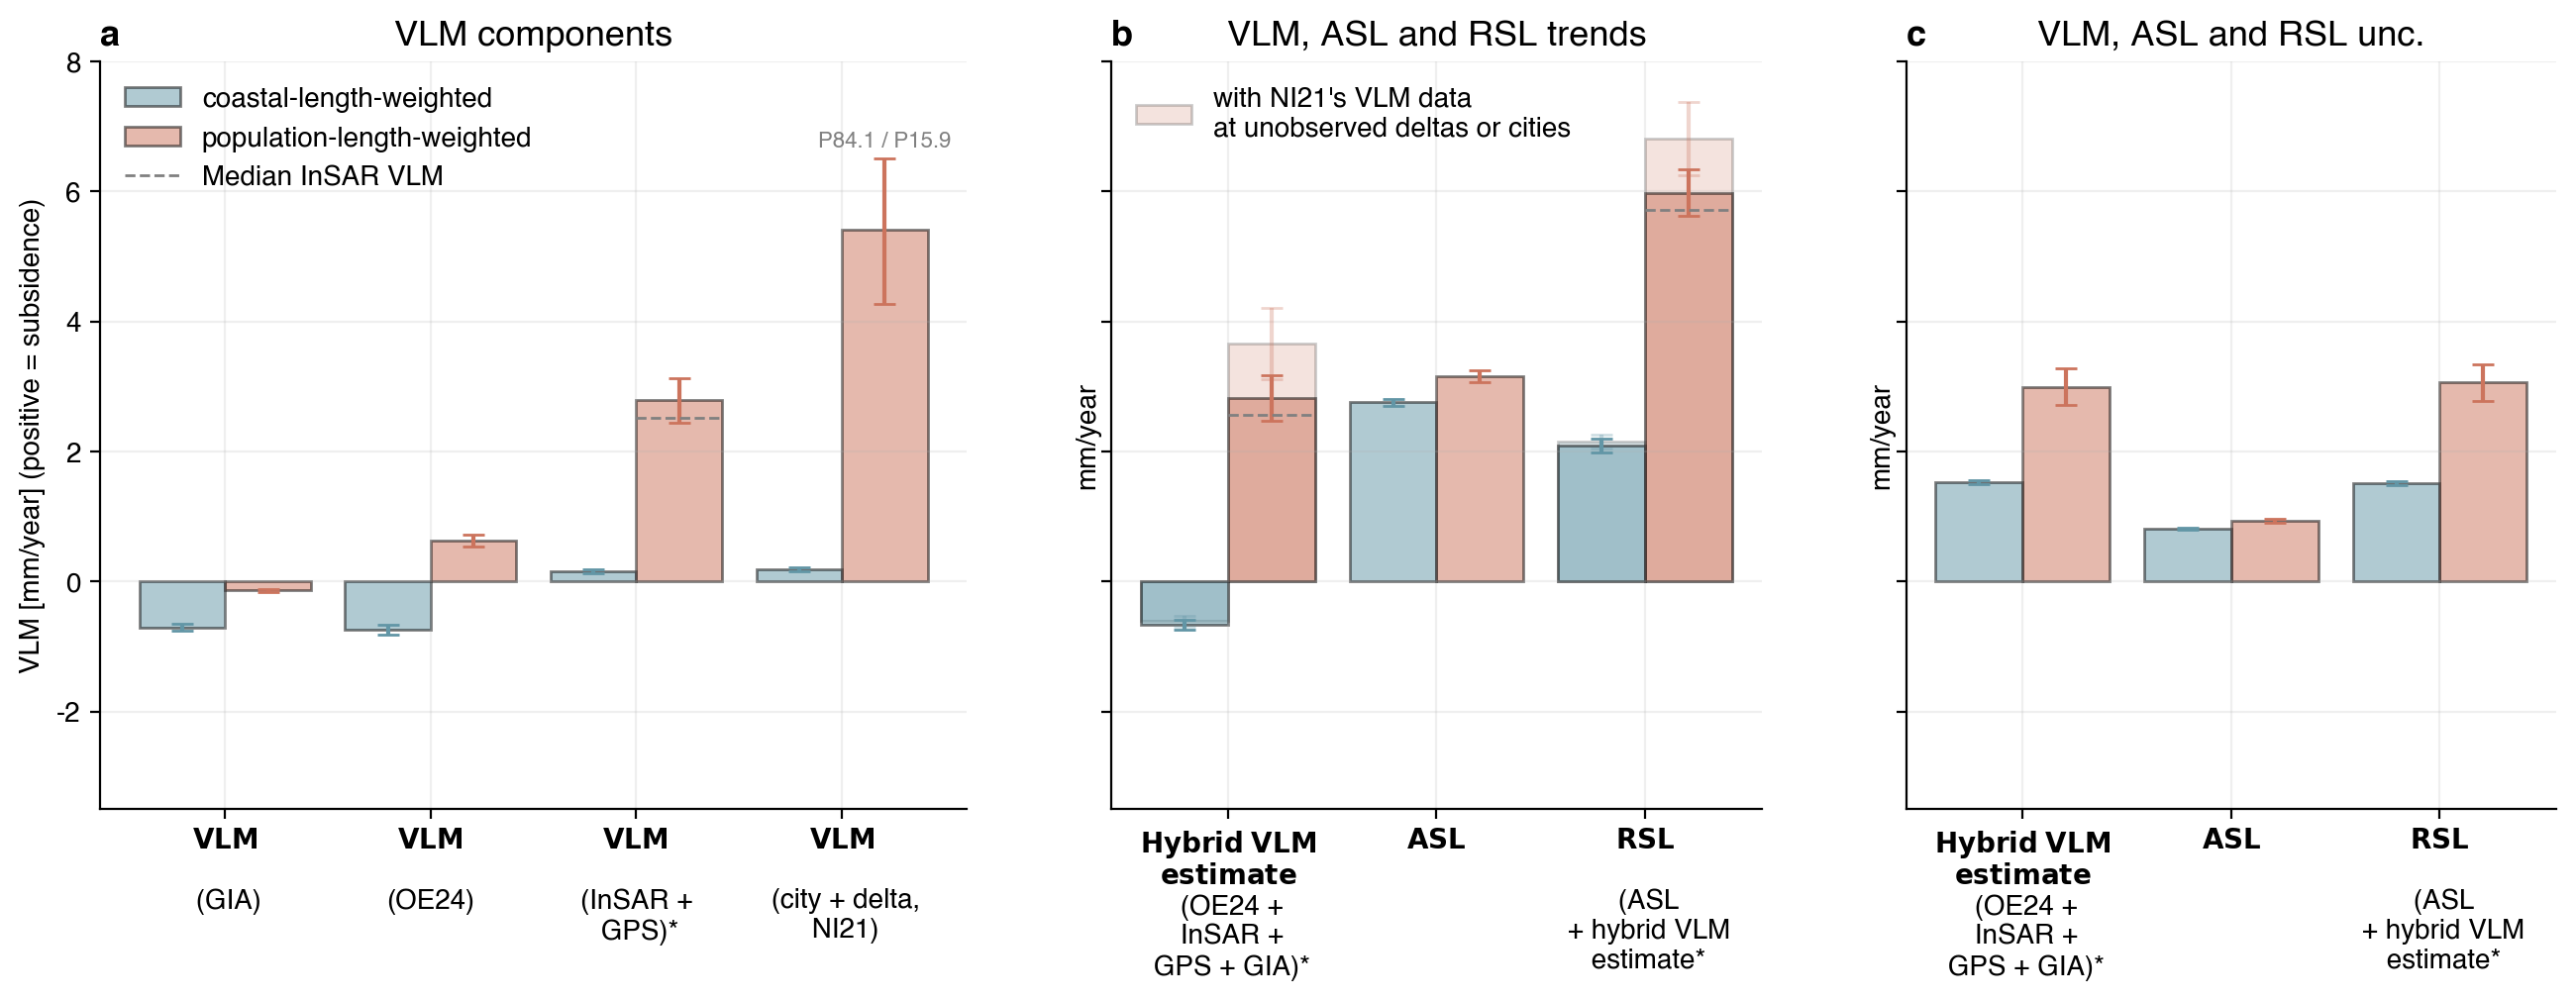

In [56]:
f, (a0, a1,a2) = plt.subplots(1, 3, gridspec_kw={'width_ratios': [4/10, 3/10, 3/10]},figsize=(16,5),sharey=True)


####### A: VLM

ax=a0
sns.axes_style("whitegrid")
add__= '_nonzero'

method = ''
bootstrap_it = 10000
test_size = 0.5

cmap_err = sns.diverging_palette(220, 20, as_cmap=True)


real_names = ['GIA','VLM_map','VLM_InSAR'+settings['Version']+method+add__,'VLM_city_delta'] # upper limit
real_names = ['GIA','VLM_map','VLM_InSAR'+settings['Version']+method+add__,'VLM_city_delta_avg']

long_names = ['$\\bf{VLM}$\n\n (GIA)','$\\bf{VLM}$ \n\n(OE24)','$\\bf{VLM}$ \n\n(InSAR +\n GPS)*','$\\bf{VLM}$\n\n (city + delta,\n NI21)']

factors = [1,1000,1000,1000,1,1,1,1,1,1,1,1]
i=0
ticks = []
use_confidence = True
for name,long_name,ff in zip(real_names,long_names,factors):
    dat_use = copy.deepcopy(ds_grouped[name].values)*-ff
    dat_use[np.isnan(dat_use)] =0
    
    if i==0:
        kwargs1 = {'label':'coastal-length-weighted'}
        kwargs2 = {'label':'population-length-weighted'}        
    else:
        kwargs1 = {}
        kwargs2 = {}
    
    if use_confidence:
        if long_name in ['$\\bf{VLM}$ \n\n(InSAR +\n GPS)*']:
            dat_use_un = copy.deepcopy(ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA']).fillna(0).values
            dat_use_un[np.isnan(ds_grouped['VLM_InSAR'+settings['Version']+'_rob_uncertainty'])]=0

            means_ = bootstrap_wavg_un(dat_use,ds_grouped.length.values,dat_use_un,it=bootstrap_it,test_size=test_size)


        else:
            means_ = bootstrap_wavg(dat_use,ds_grouped.length.values,it=bootstrap_it,test_size=test_size)
        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.length.values)
        
        means_
        a0.bar(i-0.25,mean_,color=cmap_err(0.1),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.1),'capsize':4},**kwargs1)
        ymax=np.percentile(means_,50+34.1)
        ymin=np.percentile(means_,50-34.1)
        ytop = ymax-mean_
        ybot = mean_-ymin
        a0.errorbar([i-0.25], [mean_], yerr=([ybot], [ytop]) ,color='k',**{'ecolor': cmap_err(0.1),'capsize':4})    
        
 
        if long_name in ['$\\bf{VLM}$ \n\n(InSAR +\n GPS)*']:
            dat_use_un = copy.deepcopy(ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA']).fillna(0).values
            dat_use_un[np.isnan(ds_grouped['VLM_InSAR'+settings['Version']+'_rob_uncertainty'])]=0

            means_ = bootstrap_wavg_un(dat_use,ds_grouped.pop_below_10p0_nonzero.values,dat_use_un,it=bootstrap_it,test_size=test_size)

        else:
            means_ = bootstrap_wavg(dat_use,ds_grouped.pop_below_10p0_nonzero.values,it=bootstrap_it,test_size=test_size)
        
        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)    
        a0.bar(i+0.25,mean_,color=cmap_err(0.9),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.9),'capsize':4},**kwargs2)
        ymax=np.percentile(means_,50+34.1)
        ymin=np.percentile(means_,50-34.1)
        ytop = ymax-mean_
        ybot = mean_-ymin
        a0.errorbar([i+0.25], [mean_], yerr=([ybot], [ytop]) ,color='k',**{'ecolor': cmap_err(0.9),'capsize':4})    
                
        if name =='VLM_city_delta_avg':
            a0.text(
                i + 0.25, mean_ + ytop + 0.02 * mean_,
                f"P84.1 / P15.9",
                ha='center', va='bottom', fontsize=8, color='gray'
            )

    else:
        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.length.values)
        a0.bar(i-0.25,mean_,yerr=[w_std,w_std/2],color=cmap_err(0.1),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.1),'capsize':4},**kwargs1)

    
  
        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)
        a0.bar(i+0.25,mean_,yerr=w_std,color=cmap_err(0.9),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.9),'capsize':4},**kwargs2)

    ticks.append(i)

    i=i+1.2


i=i-1.2
i=i-1.2


name = 'VLM_InSAR'+settings['Version']+'_median'+add__
dat_use = copy.deepcopy(ds_grouped[name].values)*-1000
dat_use[np.isnan(dat_use)] =0
mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)

a0.plot([i,i+0.5],[mean_,mean_],linestyle='--',color='grey',linewidth=1,label ='Median InSAR VLM')


sns.despine()
ax.set_xlabel('')
a0.set_xticks(ticks)
a0.set_xticklabels(long_names)
a0.set_ylim(-3.5,8)

handles, labels = a0.get_legend_handles_labels()
handles = handles[1:] + handles[:1]
labels  = labels[1:] + labels[:1]

# rebuild legend
leg = a0.legend(handles, labels, loc='upper left', frameon=False)

ax.set_title('a',loc='left',fontsize=main_fontsize,fontweight="bold") 
ax.set_title('VLM components',loc='center',fontsize=main_fontsize) 
a0.set_ylabel('VLM [mm/year] (positive = subsidence)')

ax.grid(alpha=0.2)



####### B: VLM + RSL

ax=a1

add__= '_nonzero'
opt=9

real_names = [ 'VLM_map_InSAR'+settings['Version']+method+'_GIA','ASL','RSL_VLM_map_InSAR'+settings['Version']+method+'_GIA']
real_names_un = ['VLM_map_InSAR'+str(int(settings['Version']))+'_combined_uncertainty_GIA','ASL_un','combined_unc_VLM_map_InSAR'+settings['Version']+method+'_rob_uncertainty_GIA']

long_names =  ['$\\bf{Hybrid}$ $\\bf{VLM}$\n$\\bf{estimate}$\n (OE24 +\n InSAR +\n GPS + GIA)*','$\\bf{ASL}$','$\\bf{RSL}$\n\n (ASL\n + hybrid VLM\n estimate*']

factors = [1000,-1000,-1000,-1000,1,1,1,1,1,1,1,1]
i=0
ticks = []

# Case: Use NI21b data at all locations where no InSAR data exists

if True:
    name = 'VLM_map_InSAR'+str(int(settings['Version'])+1)+'_GIA'

    dat_use = copy.deepcopy(ds_grouped[name].values)*-ff
    dat_use[np.isnan(dat_use)] =0
    i=0

    if use_confidence:

        # Use InSAR uncertainties 
        dat_use_un = copy.deepcopy(ds_grouped['VLM_map_InSAR'+str(int(settings['Version']))+'_combined_uncertainty_GIA']).fillna(0).values
        means_ = bootstrap_wavg_un(dat_use,ds_grouped.length.values,dat_use_un,it=bootstrap_it,test_size=test_size)

        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.length.values)

        a1.bar(i-0.25,mean_,color=cmap_err(0.1),width=0.5,edgecolor='k',alpha=0.2,error_kw={'ecolor': cmap_err(0.1),'capsize':4,'alpha':0.3})
        ymax=np.percentile(means_,50+34.1)
        ymin=np.percentile(means_,50-34.1)
        
        ytop = ymax-mean_
        ybot = mean_-ymin
        a1.errorbar([i-0.25], [mean_], yerr=([ybot], [ytop]) ,color='k',**{'ecolor': cmap_err(0.1),'capsize':4,'alpha':0.3})    

 
        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)
    
        means_ = bootstrap_wavg_un(dat_use,ds_grouped.pop_below_10p0_nonzero.values,dat_use_un,it=bootstrap_it,test_size=test_size)

        a1.bar(i+0.25,mean_,color=cmap_err(0.9),width=0.5,edgecolor='k',alpha=0.2,error_kw={'ecolor': cmap_err(0.9),'capsize':4,'alpha':0.3},
               **{'label':"with NI21's VLM data \nat unobserved deltas or cities"})
        
        ymax=np.percentile(means_,50+34.1)
        ymin=np.percentile(means_,50-34.1)
        ytop = ymax-mean_
        ybot = mean_-ymin
        a1.errorbar([i+0.25], [mean_], yerr=([ybot], [ytop]) ,color='k',**{'ecolor': cmap_err(0.9),'capsize':4,'alpha':0.3})    


    else:
        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.length.values)
        a1.bar(i-0.25,mean_,yerr=[w_std,w_std/2],color=cmap_err(0.1),width=0.5,edgecolor='k',alpha=0.2,error_kw={'ecolor': cmap_err(0.1),'capsize':4,'alpha':0.3})


        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)
        a1.bar(i+0.25,mean_,yerr=w_std,color=cmap_err(0.9),width=0.5,edgecolor='k',alpha=0.2,error_kw={'ecolor': cmap_err(0.9),'capsize':4,'alpha':0.3},**{'label':"with NI21's VLM data \nat unobserved Deltas"})




name = 'VLM_map_InSAR'+settings['Version']+'_median'+'_GIA'
dat_use = copy.deepcopy(ds_grouped[name].values)*-1000
dat_use[np.isnan(dat_use)] =0
mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)

a1.plot([i,i+0.5],[mean_,mean_],linestyle='--',color='grey',linewidth=1)



ax.grid(alpha=0.2)

name = 'RSL_map_'+data_name
i=2.4
dat_use = copy.deepcopy(ds_grouped[name].values)*ff
dat_use[np.isnan(dat_use)] =0


if use_confidence:

    dat_use_un = copy.deepcopy(ds_grouped['combined_unc_VLM_map_InSAR'+str(int(settings['Version']))+'_rob_uncertainty_GIA']).fillna(0).values
    # Use InSAR std uncertainties
    means_ = bootstrap_wavg_un(dat_use,ds_grouped.length.values,dat_use_un,it=bootstrap_it,test_size=test_size)

    

    mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.length.values)

    a1.bar(i-0.25,mean_,color=cmap_err(0.1),width=0.5,edgecolor='k',alpha=0.2,error_kw={'ecolor': cmap_err(0.1),'capsize':4,'alpha':0.3})
    ymax=np.percentile(means_,50+34.1)
    ymin=np.percentile(means_,50-34.1)
    ytop = ymax-mean_
    ybot = mean_-ymin
    a1.errorbar([i-0.25], [mean_], yerr=([ybot], [ytop]) ,color='k',**{'ecolor': cmap_err(0.1),'capsize':4,'alpha':0.3})    

    mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)
    means_ = bootstrap_wavg_un(dat_use,ds_grouped.pop_below_10p0_nonzero.values,dat_use_un,it=bootstrap_it,test_size=test_size)

    a1.bar(i+0.25,mean_,color=cmap_err(0.9),width=0.5,edgecolor='k',alpha=0.2,error_kw={'ecolor': cmap_err(0.9),'capsize':4,'alpha':0.3})
    ymax=np.percentile(means_,50+34.1)
    ymin=np.percentile(means_,50-34.1)
    ytop = ymax-mean_
    ybot = mean_-ymin
    a1.errorbar([i+0.25], [mean_], yerr=([ybot], [ytop]) ,color='k',**{'ecolor': cmap_err(0.9),'capsize':4,'alpha':0.3})    


else:
    mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.length.values)
    a1.bar(i-0.25,mean_,yerr=[w_std,w_std/2],color=cmap_err(0.1),width=0.5,edgecolor='k',alpha=0.2,error_kw={'ecolor': cmap_err(0.1),'capsize':4,'alpha':0.3})



    mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)
    a1.bar(i+0.25,mean_,yerr=w_std,color=cmap_err(0.9),width=0.5,edgecolor='k',alpha=0.2,error_kw={'ecolor': cmap_err(0.9),'capsize':4,'alpha':0.3})

i=0




for name,long_name,un_name,ff in zip(real_names,long_names,real_names_un,factors):
    dat_use = copy.deepcopy(ds_grouped[name].values)*-ff
    dat_use[np.isnan(dat_use)] =0
    

    kwargs1 = {}
    kwargs2 = {}
    
    
    if use_confidence:
        if name in [ 'VLM_map_InSAR'+settings['Version']+method+'_GIA','RSL_VLM_map_InSAR'+settings['Version']+method+'_GIA']:
            dat_use_un = copy.deepcopy(ds_grouped[un_name]).fillna(0).values
            means_ = bootstrap_wavg_un(dat_use,ds_grouped.length.values,dat_use_un,it=bootstrap_it,test_size=test_size)
        else:
            means_ = bootstrap_wavg(dat_use,ds_grouped.length.values,it=bootstrap_it,test_size=test_size)

        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.length.values)
        
        means_
        a1.bar(i-0.25,mean_,color=cmap_err(0.1),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.1),'capsize':4},**kwargs1)
        ymax=np.percentile(means_,50+34.1)
        ymin=np.percentile(means_,50-34.1)

        ytop = ymax-mean_
        ybot = mean_-ymin
        a1.errorbar([i-0.25], [mean_], yerr=([ybot], [ytop]) ,color='k',**{'ecolor': cmap_err(0.1),'capsize':4})    
        
        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)

        if name in [ 'VLM_map_InSAR'+settings['Version']+method+'_GIA','RSL_VLM_map_InSAR'+settings['Version']+method+'_GIA']:
            dat_use_un = copy.deepcopy(ds_grouped[un_name]).fillna(0).values
            means_ = bootstrap_wavg_un(dat_use,ds_grouped.pop_below_10p0_nonzero.values,dat_use_un,it=bootstrap_it,test_size=test_size)
        else:
            means_ = bootstrap_wavg(dat_use,ds_grouped.pop_below_10p0_nonzero.values,it=bootstrap_it,test_size=test_size)

        a1.bar(i+0.25,mean_,color=cmap_err(0.9),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.9),'capsize':4},**kwargs2)
        ymax=np.percentile(means_,50+34.1)
        ymin=np.percentile(means_,50-34.1)

        ytop = ymax-mean_
        ybot = mean_-ymin
        a1.errorbar([i+0.25], [mean_], yerr=([ybot], [ytop]) ,color='k',**{'ecolor': cmap_err(0.9),'capsize':4})    

    else:
        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.length.values)
        a1.bar(i-0.25,mean_,yerr=[w_std,w_std/2],color=cmap_err(0.1),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.1),'capsize':4},**kwargs1)

    

        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)
        a1.bar(i+0.25,mean_,yerr=w_std,color=cmap_err(0.9),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.9),'capsize':4},**kwargs2)
    

    ticks.append(i)

    i=i+1.2



i=i-1.2
name = 'RSL_VLM_map_InSAR'+settings['Version']+'_median'+'_GIA'
dat_use = copy.deepcopy(ds_grouped[name].values)*1000
dat_use[np.isnan(dat_use)] =0
mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)

a1.plot([i,i+0.5],[mean_,mean_],linestyle='--',color='grey',linewidth=1)



sns.despine()
ax.set_xlabel('')
a1.set_xticks(ticks)
a1.set_xticklabels(long_names)
a1.set_ylim(-3.5,8)
a1.legend(loc='upper left',frameon=False)
ax.set_title('b',loc='left',fontsize=main_fontsize,fontweight="bold") 
ax.set_title('VLM, ASL and RSL trends',loc='center',fontsize=main_fontsize) 
a1.set_ylabel('mm/year')


####### C: Uncertainties
ax=a2

add__= '_nonzero'
opt=9



real_names = ['VLM_map_InSAR'+settings['Version']+'_combined_uncertainty_GIA','ASL_uncertainty','combined_unc_VLM_map_InSAR'+settings['Version']+method+'_rob_uncertainty_GIA']
long_names =  ['$\\bf{Hybrid}$ $\\bf{VLM}$\n$\\bf{estimate}$\n (OE24 +\n InSAR +\n GPS + GIA)*','$\\bf{ASL}$','$\\bf{RSL}$\n\n (ASL\n + hybrid VLM\n estimate*']

factors = [1000,1000,1000,1000,1,1,1,1,1,1,1,1]

i=0
ticks = []
for name,long_name,ff in zip(real_names,long_names,factors):
    dat_use = copy.deepcopy(ds_grouped[name].values)*ff
    dat_use[np.isnan(dat_use)] =0

    if i==0:
        kwargs1 = {'label':'coastal length weighted'}
        kwargs2 = {'label':'population length weighted'}        
    else:
        kwargs1 = {}
        kwargs2 = {}
        
        
        
    if use_confidence:
        means_ = bootstrap_wavg(dat_use,ds_grouped.length.values,it=bootstrap_it,test_size=test_size)
        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.length.values)
        
        means_
        a2.bar(i-0.25,mean_,color=cmap_err(0.1),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.1),'capsize':4},**kwargs1)
        ymax=np.percentile(means_,50+34.1)
        ymin=np.percentile(means_,50-34.1)
        ytop = ymax-mean_
        ybot = mean_-ymin
        a2.errorbar([i-0.25], [mean_], yerr=([ybot], [ytop]) ,color='k',**{'ecolor': cmap_err(0.1),'capsize':4})    

        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)
        means_ = bootstrap_wavg(dat_use,ds_grouped.pop_below_10p0_nonzero.values,it=bootstrap_it,test_size=test_size)
        a2.bar(i+0.25,mean_,color=cmap_err(0.9),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.9),'capsize':4},**kwargs2)
        ymax=np.percentile(means_,50+34.1)
        ymin=np.percentile(means_,50-34.1)
        ytop = ymax-mean_
        ybot = mean_-ymin
        a2.errorbar([i+0.25], [mean_], yerr=([ybot], [ytop]) ,color='k',**{'ecolor': cmap_err(0.9),'capsize':4})    
      
        
    else:
        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.length.values)
        a2.bar(i-0.25,mean_,yerr=[w_std,w_std/2],color=cmap_err(0.1),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.1),'capsize':4},**kwargs1)


        mean_,w_std = weighted_avg_and_std(dat_use, ds_grouped.pop_below_10p0_nonzero.values)
        a2.bar(i+0.25,mean_,yerr=w_std,color=cmap_err(0.9),width=0.5,edgecolor='k',alpha=0.5,error_kw={'ecolor': cmap_err(0.9),'capsize':4},**kwargs2)
            

    ticks.append(i)

    i=i+1.2

sns.despine()
ax.set_xlabel('')
a2.set_xticks(ticks)
a2.set_xticklabels(long_names)
a2.set_ylim(-3.5,8)


ax.set_title('c',loc='left',fontsize=main_fontsize,fontweight="bold") 
ax.grid(alpha=0.2)
ax.set_title('VLM, ASL and RSL unc.',loc='center',fontsize=main_fontsize) 
a2.set_ylabel('mm/year')


plt.savefig(settings['plot_main'] + 'Figure_3.png',bbox_inches='tight')
plt.savefig(settings['plot_main'] + 'Figure_3.pdf',bbox_inches='tight')


plt.show()


# Table 1

In [ ]:
def compute_and_average_stats(ds_grouped,vals_,mask_data=False,opt=str(8),niuse='VLM_map_delta_city'):
    """
    
    
    """

    add_='_GIA'
    data_all = []
    values_names = ['ASL','RSL','VLM']
    types_all = ['VLM map only','VLM  + InSAR', 'VLM + delta + city',]
    sub_data_all = ['VLM_map','VLM_map_InSAR'+opt,niuse]

    if mask_data:
        vals_ = ds_grouped.sel({'x':~np.isnan(ds_grouped['ASL_plus_GIA'])}).to_dataframe()
    
    for types,subdata in zip(types_all,sub_data_all):
        subdata = subdata + add_

        # for weights in ['length','pop_below_10p0']:
        data_stats = []

        values_loop =  ['ASL','RSL_'+subdata,subdata]
        for val_name in values_loop:

            w_average,w_std = weighted_avg_and_std(vals_.dropna(subset=[val_name,'pop_below_10p0'])[val_name], vals_.dropna(subset=[val_name,'pop_below_10p0'])['pop_below_10p0'])
            w_average_coast,w_std_coast = weighted_avg_and_std(vals_.dropna(subset=[val_name,'pop_below_10p0'])[val_name], vals_.dropna(subset=[val_name,'pop_below_10p0'])['length'])

            data_stats.append(pd.DataFrame([w_average_coast,w_std_coast,w_average,w_std],
                              index=['mean (weighted by coastal length)',r'$1\sigma$ (weighted by coastal length)','mean (weighted by pop)',r'$1\sigma$ (weighted by pop.)']) *1000.)

        data_all.append(np.round(pd.concat(data_stats,axis=1,keys =values_names),2))
    #return data_all
    data_adjusted = []
    data_adjusted.append(data_all[0])
    for dta_ in data_all[1:]:
        data_adjusted.append(dta_[['RSL','VLM']])
    return pd.concat(data_all,keys=types_all,axis=1),data_all,types_all,data_adjusted


data_allc,data_all,types_all,data_adjusted = compute_and_average_stats(ds_grouped,vals_,mask_data=False,opt=settings['Version'],niuse='VLM_map_delta_city_avg')
pd.concat(data_adjusted,keys=types_all,axis=1)


VLM map only             VLM  + InSAR  \
                                                ASL   RSL   VLM          RSL   
                                                  0     0     0            0   
mean (weighted by coastal length)              2.76  1.88  0.88         2.09   
$1\sigma$ (weighted by coastal length)         1.98  3.58  2.67         3.91   
mean (weighted by pop)                         3.15  3.77 -0.62         5.98   
$1\sigma$ (weighted by pop.)                   1.10  1.31  1.18         4.18   

                                             VLM + delta + city         
                                         VLM                RSL    VLM  
                                           0                  0      0  
mean (weighted by coastal length)       0.67               2.03   0.73  
$1\sigma$ (weighted by coastal length)  3.05               4.11   3.37  
mean (weighted by pop)                 -2.83               8.62  -5.46  
$1\sigma$ (weighted by pop.)            4.06              12.25  12.32

# SI Figures

## SI Figure 4

In [ ]:
gps = xr.open_dataset(settings['data_in']+'NGL_GNSS/Blewitt_NGL142025_MIDAS.nc')
gps=gps.sel({'x':(gps['duration']>=2) & (gps['trend_un']<5) & (abs(gps['trend'])<100)})
gps_x,ds_grouped_x = sl(ds_grouped.x).couple(gps.x,limit=50)
ds_grouped['gps_index']=copy.deepcopy(ds_grouped['test_val']*np.nan)
ds_grouped['gps_index'][:] = gps_x.data.values

names_country = [name[:7] for name in ds_grouped.name.values]
ds_grouped['names_country'] = copy.deepcopy(ds_grouped['name'])
ds_grouped['names_country'][:]=names_country
ds_grouped_sum = ds_grouped.groupby('names_country').sum()

country_data = pd.DataFrame(ds_grouped_sum['names_country'].values)
test_out_std = ds_grouped[['RSL_VLM_map_InSAR6_GIA','names_country','pop_below_10p0']].groupby('names_country').apply(lambda x: np.sqrt(np.sum((x['RSL_VLM_map_InSAR6_GIA']-x['RSL_VLM_map_InSAR6_GIA'].mean(dim='x'))**2*x['pop_below_10p0'])/np.sum(x['pop_below_10p0'])) if len(x) >0 else 0)*1000.

test_out = ds_grouped[['RSL_VLM_map_InSAR6_GIA','names_country','pop_below_10p0']].groupby('names_country').apply(lambda x: np.sum(x['RSL_VLM_map_InSAR6_GIA']*x['pop_below_10p0'])/np.sum(x['pop_below_10p0']) if len(x) >0 else 0)*1000.
test_out_vlm = ds_grouped[['RSL_VLM_map_InSAR6_GIA','names_country','pop_below_10p0','VLM_map_InSAR6_GIA']].groupby('names_country').apply(lambda x: np.sum(x['VLM_map_InSAR6_GIA']*x['pop_below_10p0'])/np.sum(x['pop_below_10p0']) if len(x) >0 else 0)*1000.

pop_country = ds_grouped[['RSL_VLM_map_InSAR6_GIA','names_country','pop_below_10p0']].groupby('names_country').apply(lambda x: np.sum(x['pop_below_10p0']))

sum_gps = ds_grouped[['RSL_VLM_map_InSAR6_GIA','names_country','pop_below_10p0','gps_index']].groupby('names_country').apply(lambda x: x['gps_index'].count(dim='x'))
sum_insar = ds_grouped[['RSL_VLM_map_InSAR6_GIA','names_country','pop_below_10p0','gps_index','VLM_InSAR3.03']].groupby('names_country').apply(lambda x: x['VLM_InSAR3.03'].count(dim='x'))


country_data['mean'] = test_out
country_data['vlm'] = test_out_vlm
country_data['std'] = test_out_std
country_data['NAMES'] = count_names
country_data['pop_country'] = pop_country
country_data['sum_gps'] = sum_gps
country_data['sum_insar'] = sum_insar

data_sorted = country_data.sort_values('mean',ascending=False)
data_sorted=data_sorted[data_sorted['std']!=0]


data_sorted.loc[data_sorted[0]=='CLS_CYM','NAMES']='Cayman Islands'
data_sorted.loc[data_sorted[0]=='CLS_TCA','NAMES']='Turks and Caicos Islands'
data_sorted.loc[data_sorted[0]=='CLS_SPM','NAMES']='Saint Pierre and Miquelon'
data_sorted.loc[data_sorted[0]=='CLS_CUB','NAMES']='Cuba'
data_sorted.loc[data_sorted[0]=='CLS_NLD','NAMES']='Netherlands'

data_sorted.loc[data_sorted[0]=='CLS_PYF','NAMES']='French Polynesia'
data_sorted.loc[data_sorted[0]=='CLS_FRO','NAMES']='Faroe Islands'
data_sorted.loc[data_sorted[0]=='CLS_GLP','NAMES']='Guadeloupe'
data_sorted.loc[data_sorted[0]=='CLS_GRL','NAMES']='Greenland'
data_sorted.loc[data_sorted[0]=='CLS_FIN','NAMES']='Finnland'
data_sorted.loc[data_sorted[0]=='CLS_ALA','NAMES']='Åland'

data_sorted.loc[data_sorted[0]=='CLS_VGB','NAMES']='British Virgin Islands'
data_sorted.loc[data_sorted[0]=='CLS_VIR','NAMES']='United States Virgin Islands'

data_sorted = data_sorted[(data_sorted['sum_gps']>3) | (data_sorted['sum_insar']>3) ]


swap
nearest
x
50


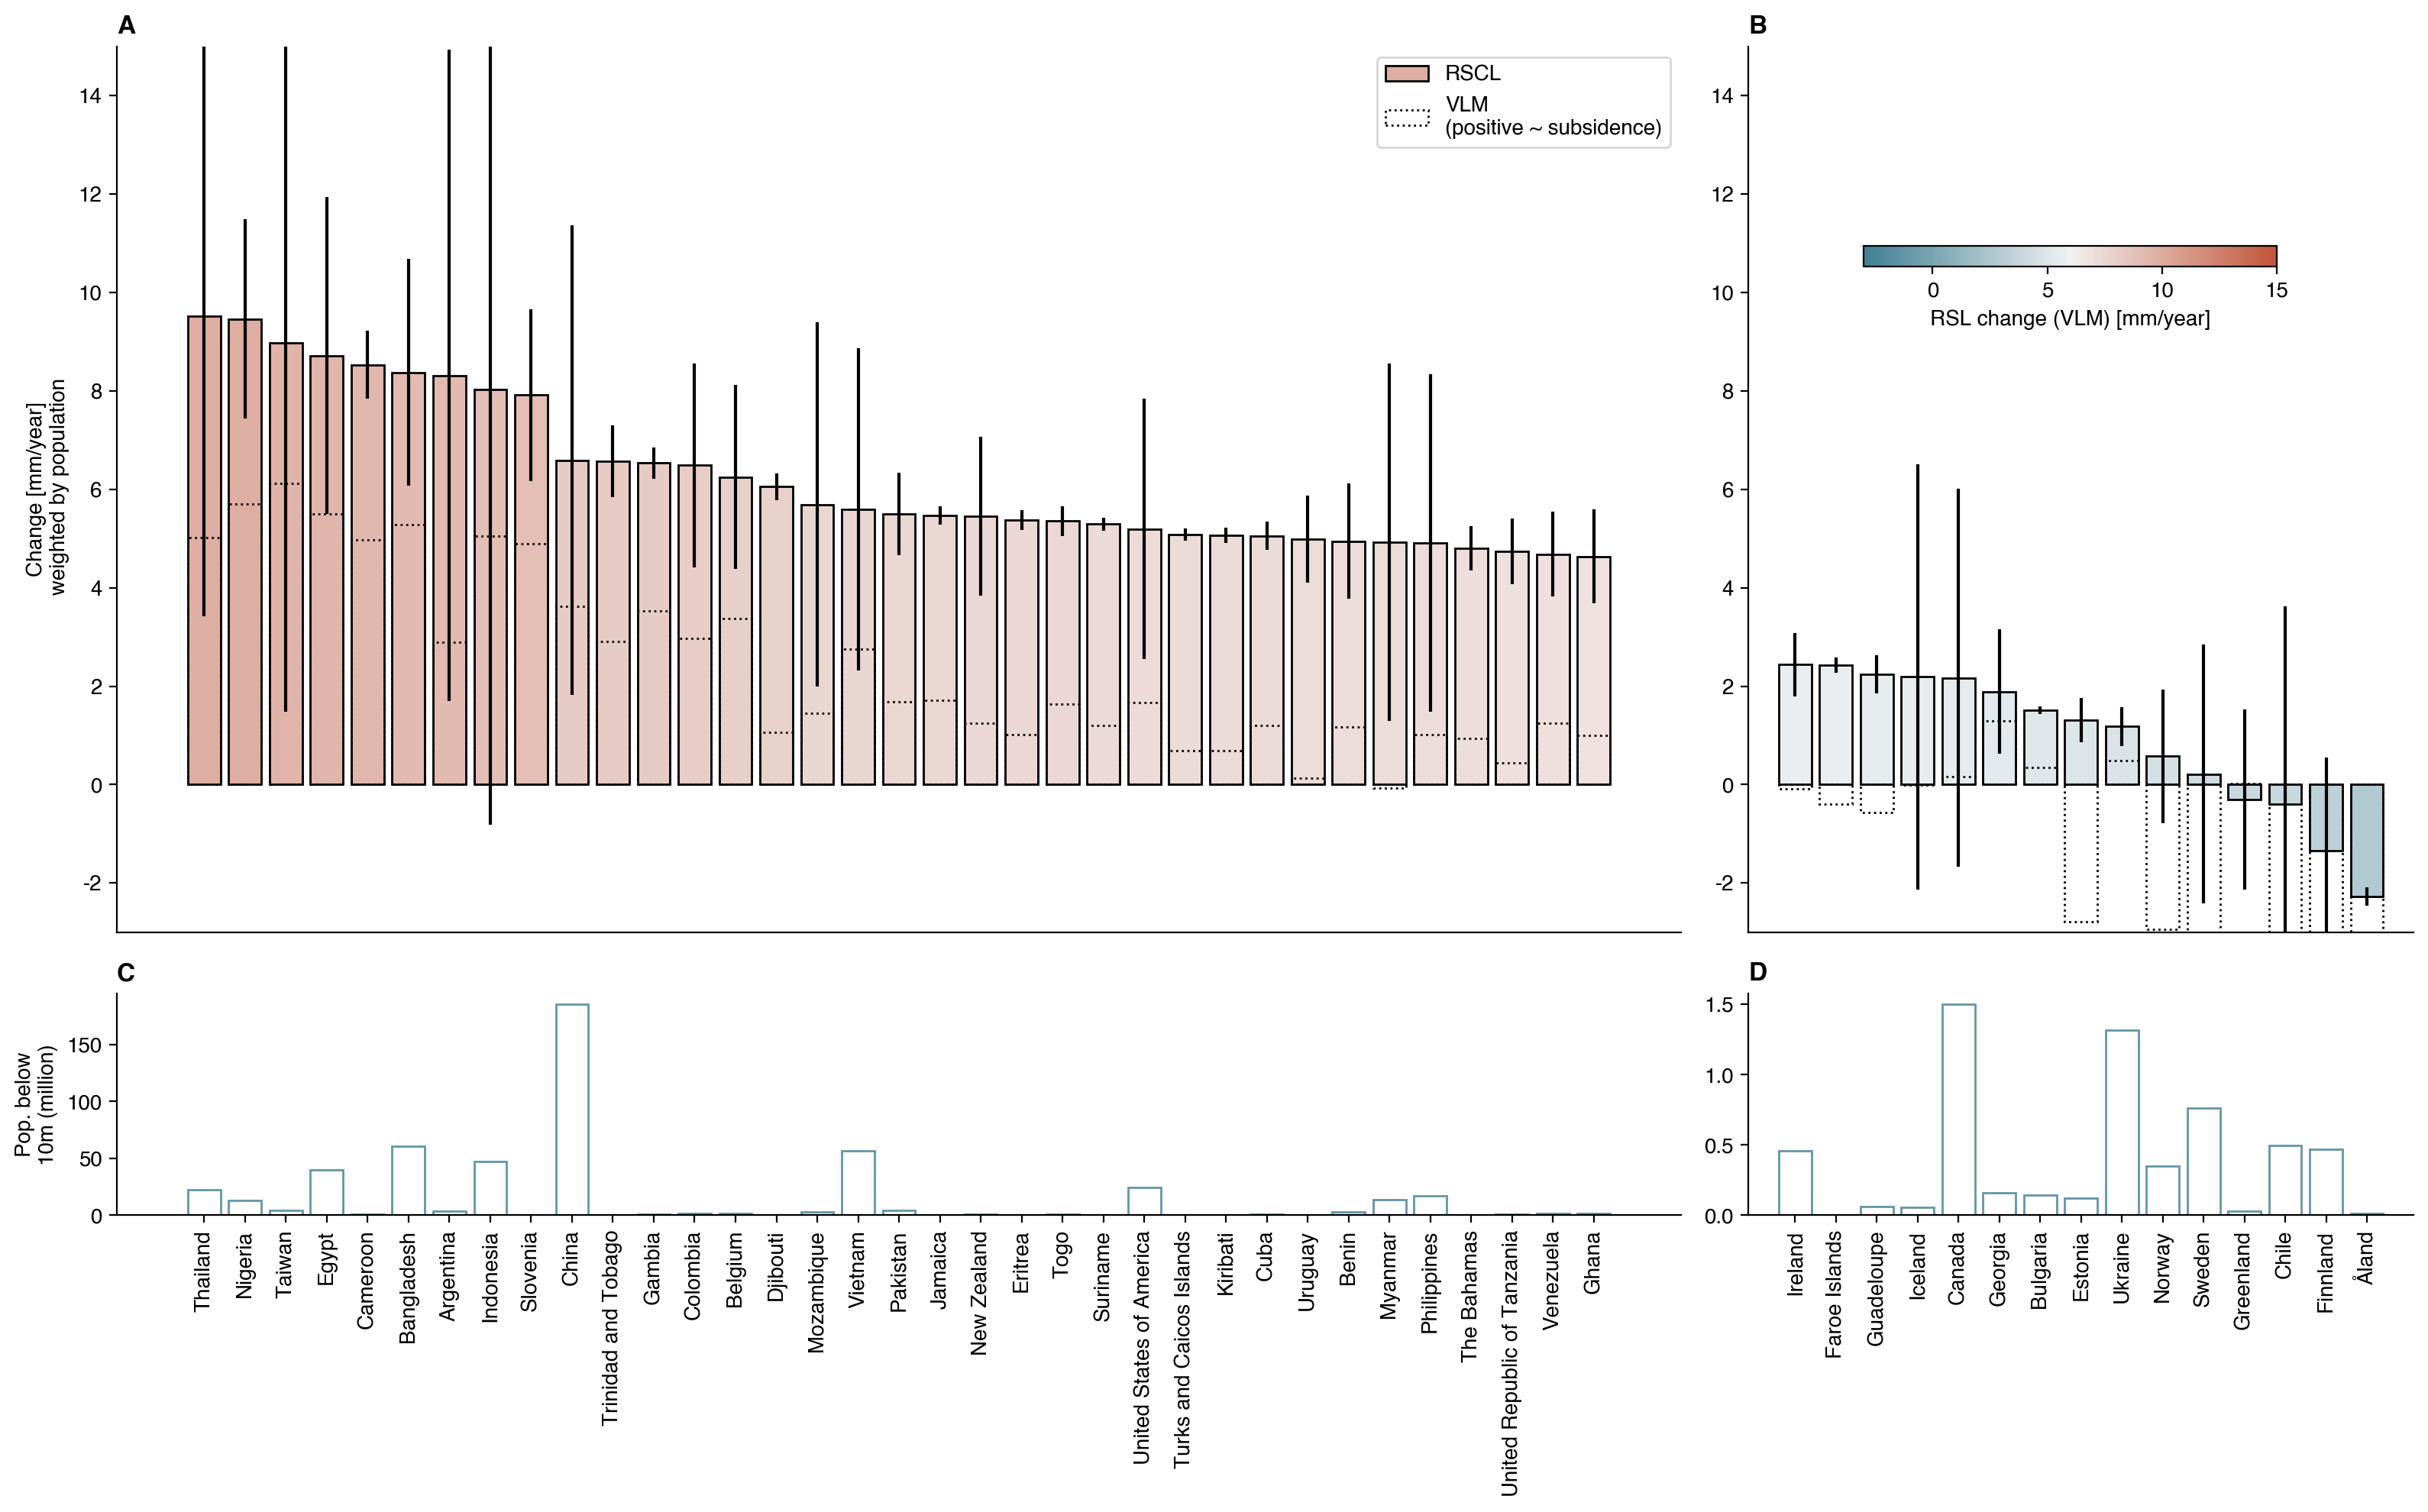

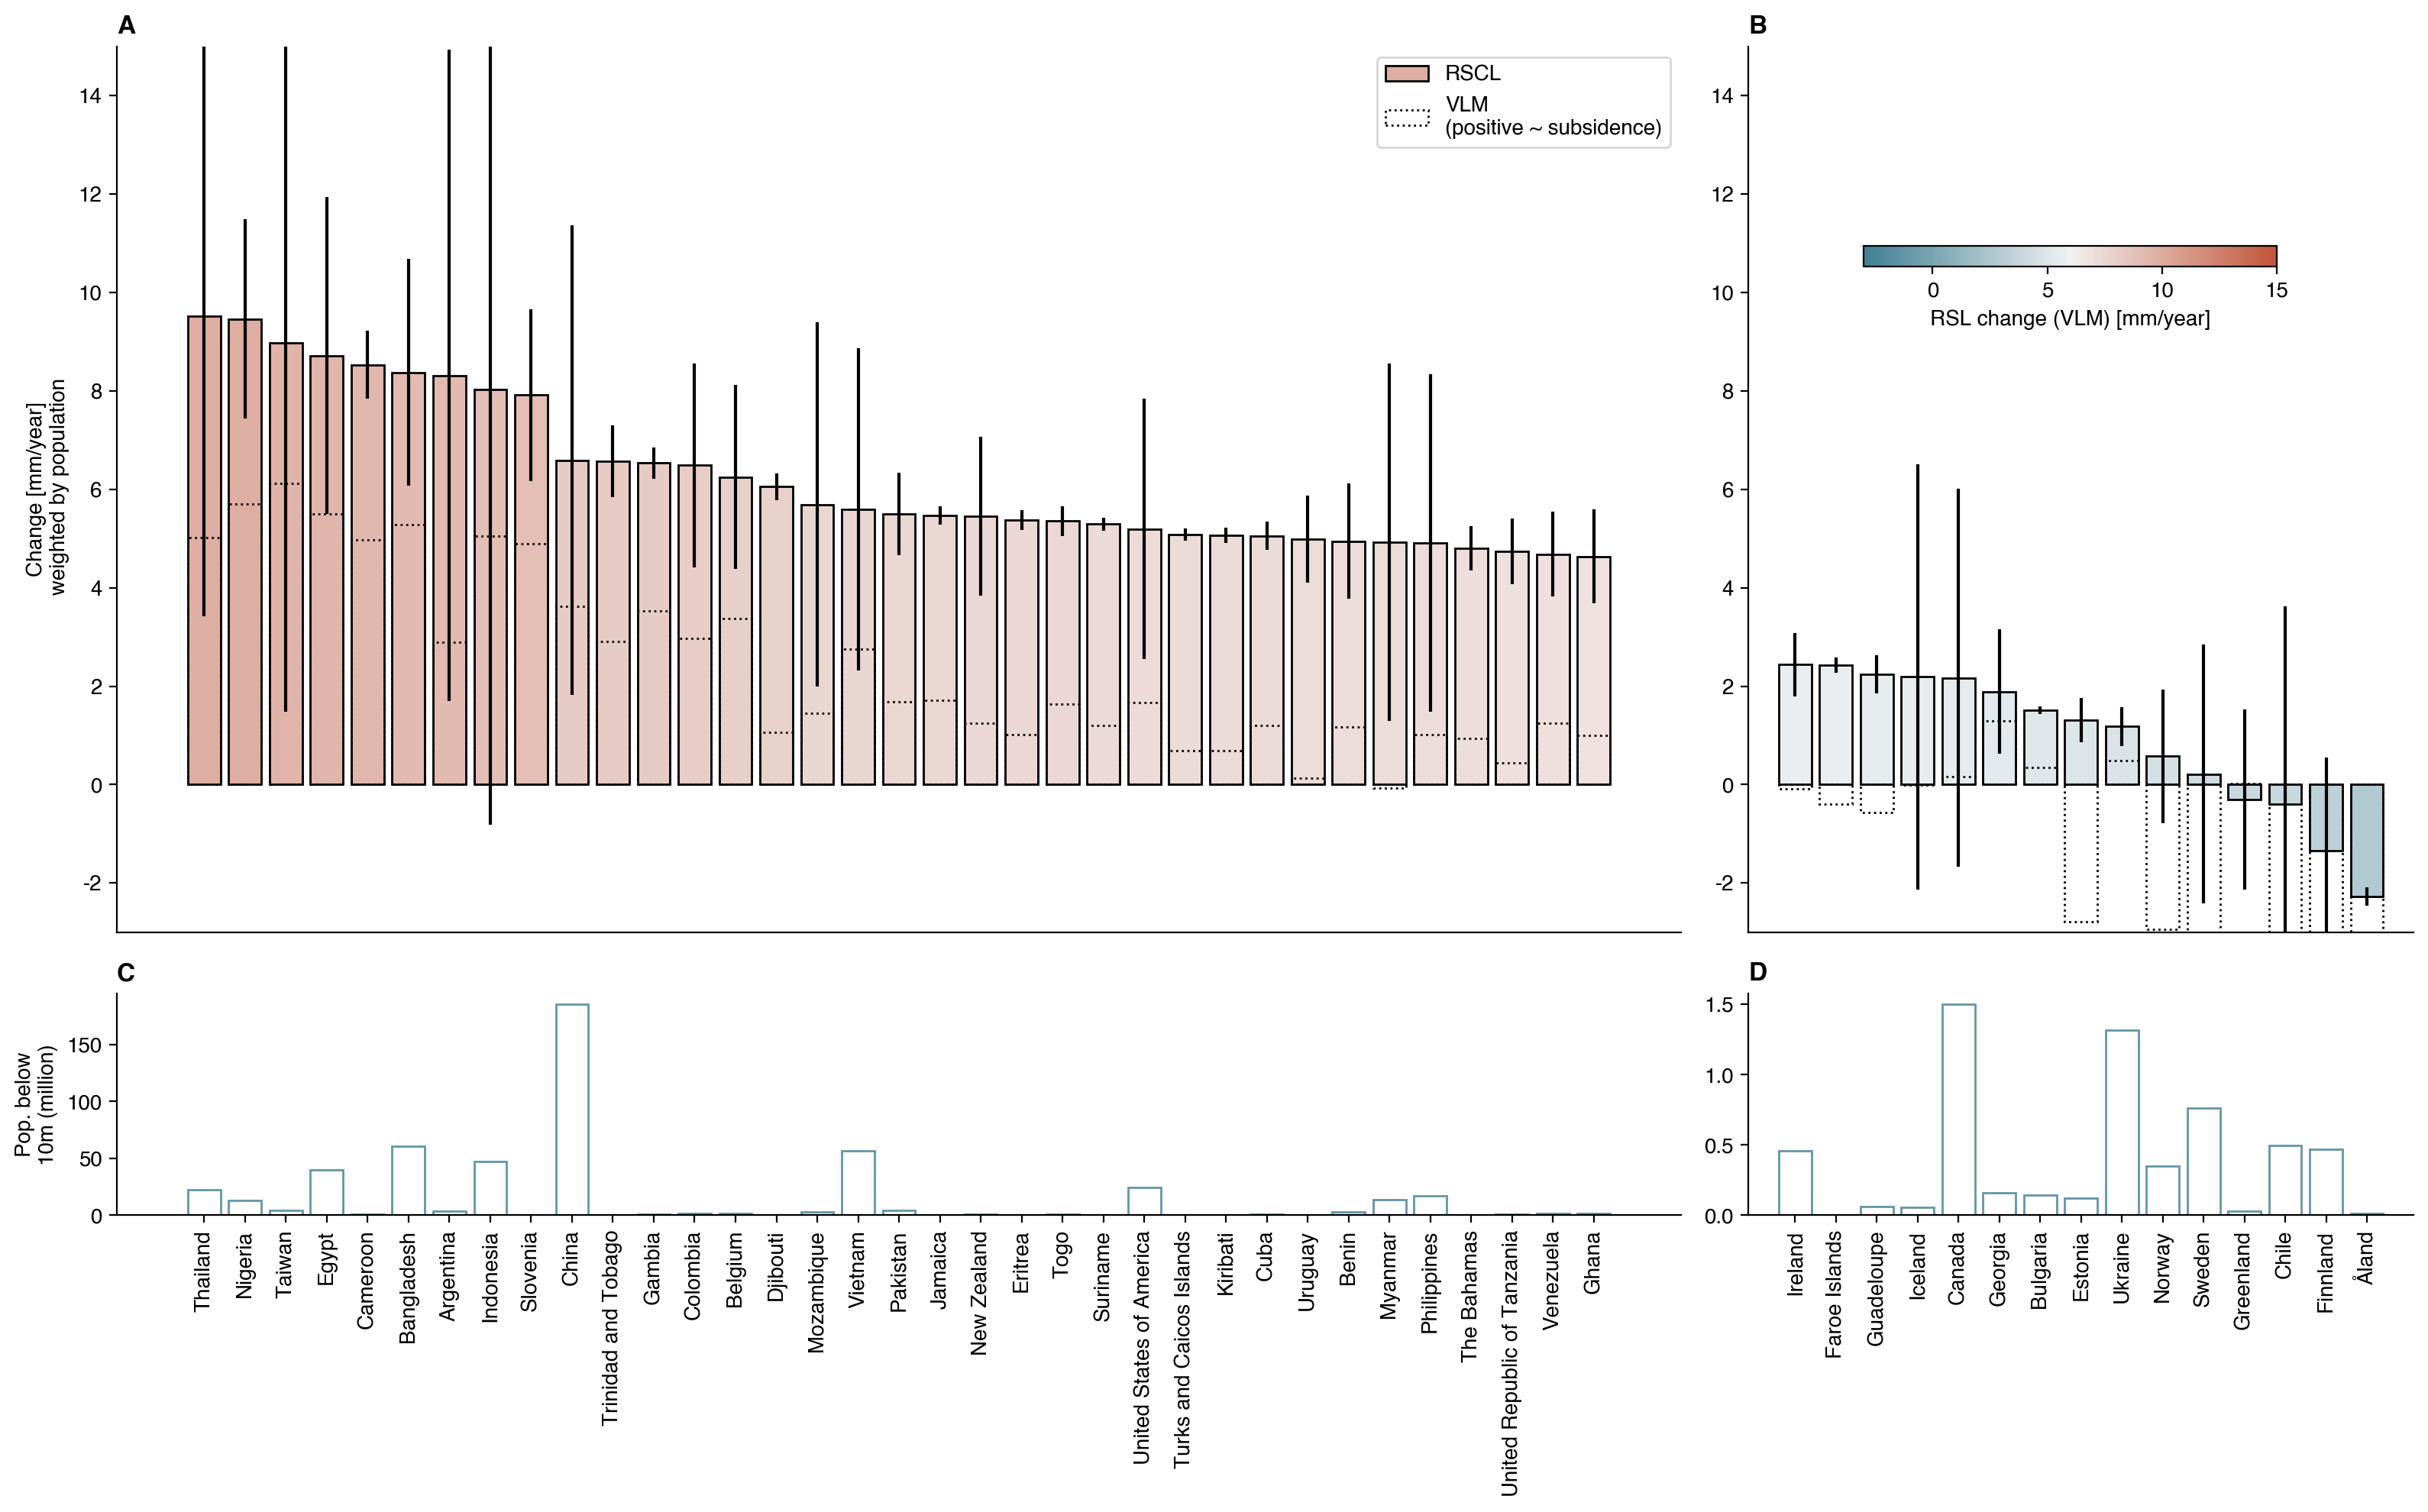

In [59]:
fig,axs = plt.subplots(2,2,figsize=(16,10),gridspec_kw={'width_ratios':[0.8,0.34,],'height_ratios':[0.8,0.2,]})
fontsize_title = 12
ax=axs[0,0]
range_=[-3,15]
many = 35
ref=3-15

data_sorted = data_sorted[data_sorted['NAMES']!='-']

ax.bar(data_sorted['NAMES'][:many], data_sorted['mean'][:many],color=cmap_err((data_sorted['mean'][:many]+12)/(2*15)),edgecolor='k',yerr=data_sorted['std'][:many],label='RSCL')
ax.bar(data_sorted['NAMES'][:many], data_sorted['vlm'][:many]*-1,edgecolor='k',fill=False,linestyle=':',label='VLM\n(positive ~ subsidence)')

ax.set_ylim(-3,15)
plt.setp( ax.xaxis.get_majorticklabels(), rotation=90 )
ax.set_ylabel('Change [mm/year]\n weighted by population')
ax.set_xticks([])
ax.set_title('A',loc='left',fontsize=fontsize_title,fontweight="bold")  
ax.legend()

ax=axs[1,0]
val = 'pop_below_10p0SUM'
ax.bar(data_sorted['NAMES'][:many], data_sorted['pop_country'][:many]/1000000,label='popullation below 10m',fill=False,edgecolor=cmap_err(0.1))
ax.set_ylabel('Pop. below\n10m (million)')

plt.setp(ax.xaxis.get_majorticklabels(), rotation=90 )
plt.tight_layout()
ax.set_title('C',loc='left',fontsize=fontsize_title,fontweight="bold")  
ax.grid(False)
sns.despine()

ax=axs[0,1]
many=15
ax.bar(data_sorted['NAMES'][~np.isnan(data_sorted['mean'])][-many:], data_sorted['mean'][~np.isnan(data_sorted['mean'])][-many:],yerr=data_sorted['std'][~np.isnan(data_sorted['mean'])][-many:],
       color=cmap_err((data_sorted['mean'][~np.isnan(data_sorted['mean'])][-many:]+12)/(2*15)),edgecolor='k')

ax.bar(data_sorted['NAMES'][~np.isnan(data_sorted['mean'])][-many:], data_sorted['vlm'][~np.isnan(data_sorted['mean'])][-many:]*-1,edgecolor='k',fill=False,linestyle=':',label='VLM')


sns.despine()
ax.set_ylim(-3,15)
plt.setp( ax.xaxis.get_majorticklabels(), rotation=90 )
ax.set_xticks([])
ax.set_title('B',loc='left',fontsize=fontsize_title,fontweight="bold")  
ax=axs[1,1]
val = 'pop_below_10p0SUM'
ax.bar(data_sorted['NAMES'][~np.isnan(data_sorted['mean'])][-many:], data_sorted['pop_country'][~np.isnan(data_sorted['mean'])][-many:]/1000000,label='popullation below 10m',fill=False,edgecolor=cmap_err(0.1))
#ax.set_ylabel('Pop. below\n10m (million)')
ax.set_title('D',loc='left',fontsize=fontsize_title,fontweight="bold")  
ax.grid(False)


vmin, vmax = -3, 15
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_err)
sm.set_array([])

axB = axs[0, 1]
pos = axB.get_position()
height_frac = 0.3   # relative height of new axis
pad = 0.01          # vertical spacing


axB_top = fig.add_axes([
    pos.x0+0.05,
    pos.y1-0.2,
    pos.width-0.1,
    pos.height * height_frac
])


cbar = fig.colorbar(
    sm,
    ax= axB_top ,
    fraction=0.4,orientation='horizontal'
)
cbar.set_label('RSL change (VLM) [mm/year]')
axB_top.axis('off')

plt.setp(ax.xaxis.get_majorticklabels(), rotation=90 )


plt.savefig(settings['plot_ext'] + 'SI4.png',bbox_inches='tight')
plt.savefig(settings['plot_ext'] + 'SI4.pdf',bbox_inches='tight')


plt.tight_layout()
plt.show()




# SI Figure 4: Cities

In [ ]:
files = ['Alexandria_TD065_interpolated.nc',
        'Ahmedabad_TD034_interpolated.nc',
        'Barcelona_TA132_interpolated.nc',
        'Abidjan_TA118_interpolated.nc',
        'Bangkok_TD062_interpolated.nc',
        'BuenosAires_TD170_interpolated.nc',
        'Chennai_TD092_interpolated.nc',
        'Chittagong_TD077_interpolated.nc',
        'Dalian_TA098_interpolated.nc',
        'DaresSalaam_TD006_interpolated.nc',
        'Dhaka_TD150_interpolated.nc',
        'Dongguan_TA011_interpolated.nc',
        'Foshan_TA011_interpolated.nc',
        'Fukuoka_TD163_interpolated.nc',
        'Guangzhou_TA011_interpolated.nc',
        'Hangzhou_TA069_interpolated.nc',
        'HoChiMinhCity_TD018_interpolated.nc',
        'HongKong_TA011_interpolated.nc',
        'Houston_TD143_interpolated.nc',
        'Istanbul_TD138_interpolated.nc',
        'Jakarta_TA098_interpolated.nc',
        'Karachi_TD078_interpolated.nc',
        'Kolkata_TD048_interpolated.nc',
        'Lagos_TD095_interpolated.nc',
        'Lima_TD069_interpolated.nc',
        'London_TD081_interpolated.nc',
        'LosAngeles_TD071_interpolated.nc',
        'Luanda_TA131_interpolated.nc',
        'Manila_TD032_interpolated.nc',
        'Miami_TA048_interpolated.nc',
        'Mumbai_TD034_interpolated.nc',
        'Nagoya_TD119_interpolated.nc',
        'Nanjing_TA069_interpolated.nc',
        'NewYork_TA033_interpolated.nc',
        'Osaka_TD017_interpolated.nc',
        'Philadelphia_TA106_interpolated.nc',
        'Qingdao_TD076_interpolated.nc',
        'RiodeJaneiro_TD155_interpolated.nc',
        'SaintPetersburg_TD007_interpolated.nc',
        'Seoul_TD134_interpolated.nc',
        'Shanghai_TA171_interpolated.nc',
        'Singapore_TD018_interpolated.nc',
        'Surat_TD034_interpolated.nc',
        'Suzhou_TA171_interpolated.nc',
        'Tianjin_TD149_interpolated.nc',
        'Tokyo_TD046_interpolated.nc',
        'Washington,D.C._TA004_interpolated.nc',
        'Yangon_TD033_interpolated.nc']

# Same cities as used in Tay et al., 2022; https://www.nature.com/articles/s41893-022-00947-z

In [62]:
cols = ['VLM_InSAR3.03','VLM_map_InSAR6_combined_uncertainty_GIA','pop_below_10p0','GIA','VLM_map','VLM_map_uncertainty','VLM_InSAR6']

only_InSAR = copy.deepcopy(ds_grouped[cols])
cmap_err = sns.diverging_palette(220, 20, as_cmap=True)

only_InSAR['VLM_InSAR3.03_uncertainty'] = copy.deepcopy(only_InSAR['VLM_map_InSAR6_combined_uncertainty_GIA'])
only_InSAR['VLM_InSAR6_uncertainty'] = copy.deepcopy(only_InSAR['VLM_map_InSAR6_combined_uncertainty_GIA'])

only_InSAR['VLM_InSAR6_uncertainty'][np.isnan(only_InSAR['VLM_InSAR6'])]=np.nan
only_InSAR['VLM_InSAR3.03_uncertainty'][np.isnan(only_InSAR['VLM_InSAR3.03'])]=np.nan

In [63]:
data_sets= []
names_not =[]
for file in files[:]:
    tay = xr.open_dataset(dir_Tay + file)
    print(file)
    data = sl(only_InSAR).box([tay.lon.min()-2,tay.lon.max()+2,tay.lat.min()-2,tay.lat.max()+2]).data

    limit = 50
    if file == 'BuenosAires_TD170_interpolated.nc':
        limit = 10
    if len(data.x)>0:
        if len(data.x)==1:
            data = xr.concat([data,data],dim='x')
        data['name'] = file[:-22]
        insar_x,data_x = sl(tay.x).couple(data.x,limit=limit)
        data = data.sel({'x':data_x.data.dropna(dim='x').astype(int).values})
        data_sets.append(data)
    else:
        names_not.append(file[:-22])
        print(file[:-22])
        print(tay.lon.min().values)


Alexandria_TD065_interpolated.nc
nearest
x
50
Ahmedabad_TD034_interpolated.nc
nearest
x
50
Barcelona_TA132_interpolated.nc
nearest
x
50
Abidjan_TA118_interpolated.nc
nearest
x
50
Bangkok_TD062_interpolated.nc
nearest
x
50
BuenosAires_TD170_interpolated.nc
nearest
x
10
Chennai_TD092_interpolated.nc
nearest
x
50
Chittagong_TD077_interpolated.nc
nearest
x
50
Dalian_TA098_interpolated.nc
nearest
x
50
DaresSalaam_TD006_interpolated.nc
nearest
x
50
Dhaka_TD150_interpolated.nc
nearest
x
50
Dongguan_TA011_interpolated.nc
nearest
x
50
Foshan_TA011_interpolated.nc
nearest
x
50
Fukuoka_TD163_interpolated.nc
nearest
x
50
Guangzhou_TA011_interpolated.nc
nearest
x
50
Hangzhou_TA069_interpolated.nc
nearest
x
50
HoChiMinhCity_TD018_interpolated.nc
nearest
x
50
HongKong_TA011_interpolated.nc
nearest
x
50
Houston_TD143_interpolated.nc
nearest
x
50
Istanbul_TD138_interpolated.nc
nearest
x
50
Jakarta_TA098_interpolated.nc
nearest
x
50
Karachi_TD078_interpolated.nc
nearest
x
50
Kolkata_TD048_interpolated.n

In [64]:
cols = ['VLM_InSAR3.03','VLM_InSAR3.03_uncertainty','pop_below_10p0','GIA','VLM_map','VLM_map_uncertainty','VLM_InSAR6','VLM_InSAR6_uncertainty']

data_out = xr.concat(data_sets,dim='x')
MEAN = data_out.groupby('name').mean()[cols].to_dataframe()
STD = data_out.groupby('name').std()[cols].to_dataframe()
STD.columns = [col + '_std' for col in STD.columns]
SUM = data_out.groupby('name').sum()[cols].to_dataframe()
SUM.columns = [col + 'SUM' for col in SUM.columns]
ALL_ = pd.concat([MEAN,STD,SUM],axis=1).sort_values(by='VLM_InSAR3.03')

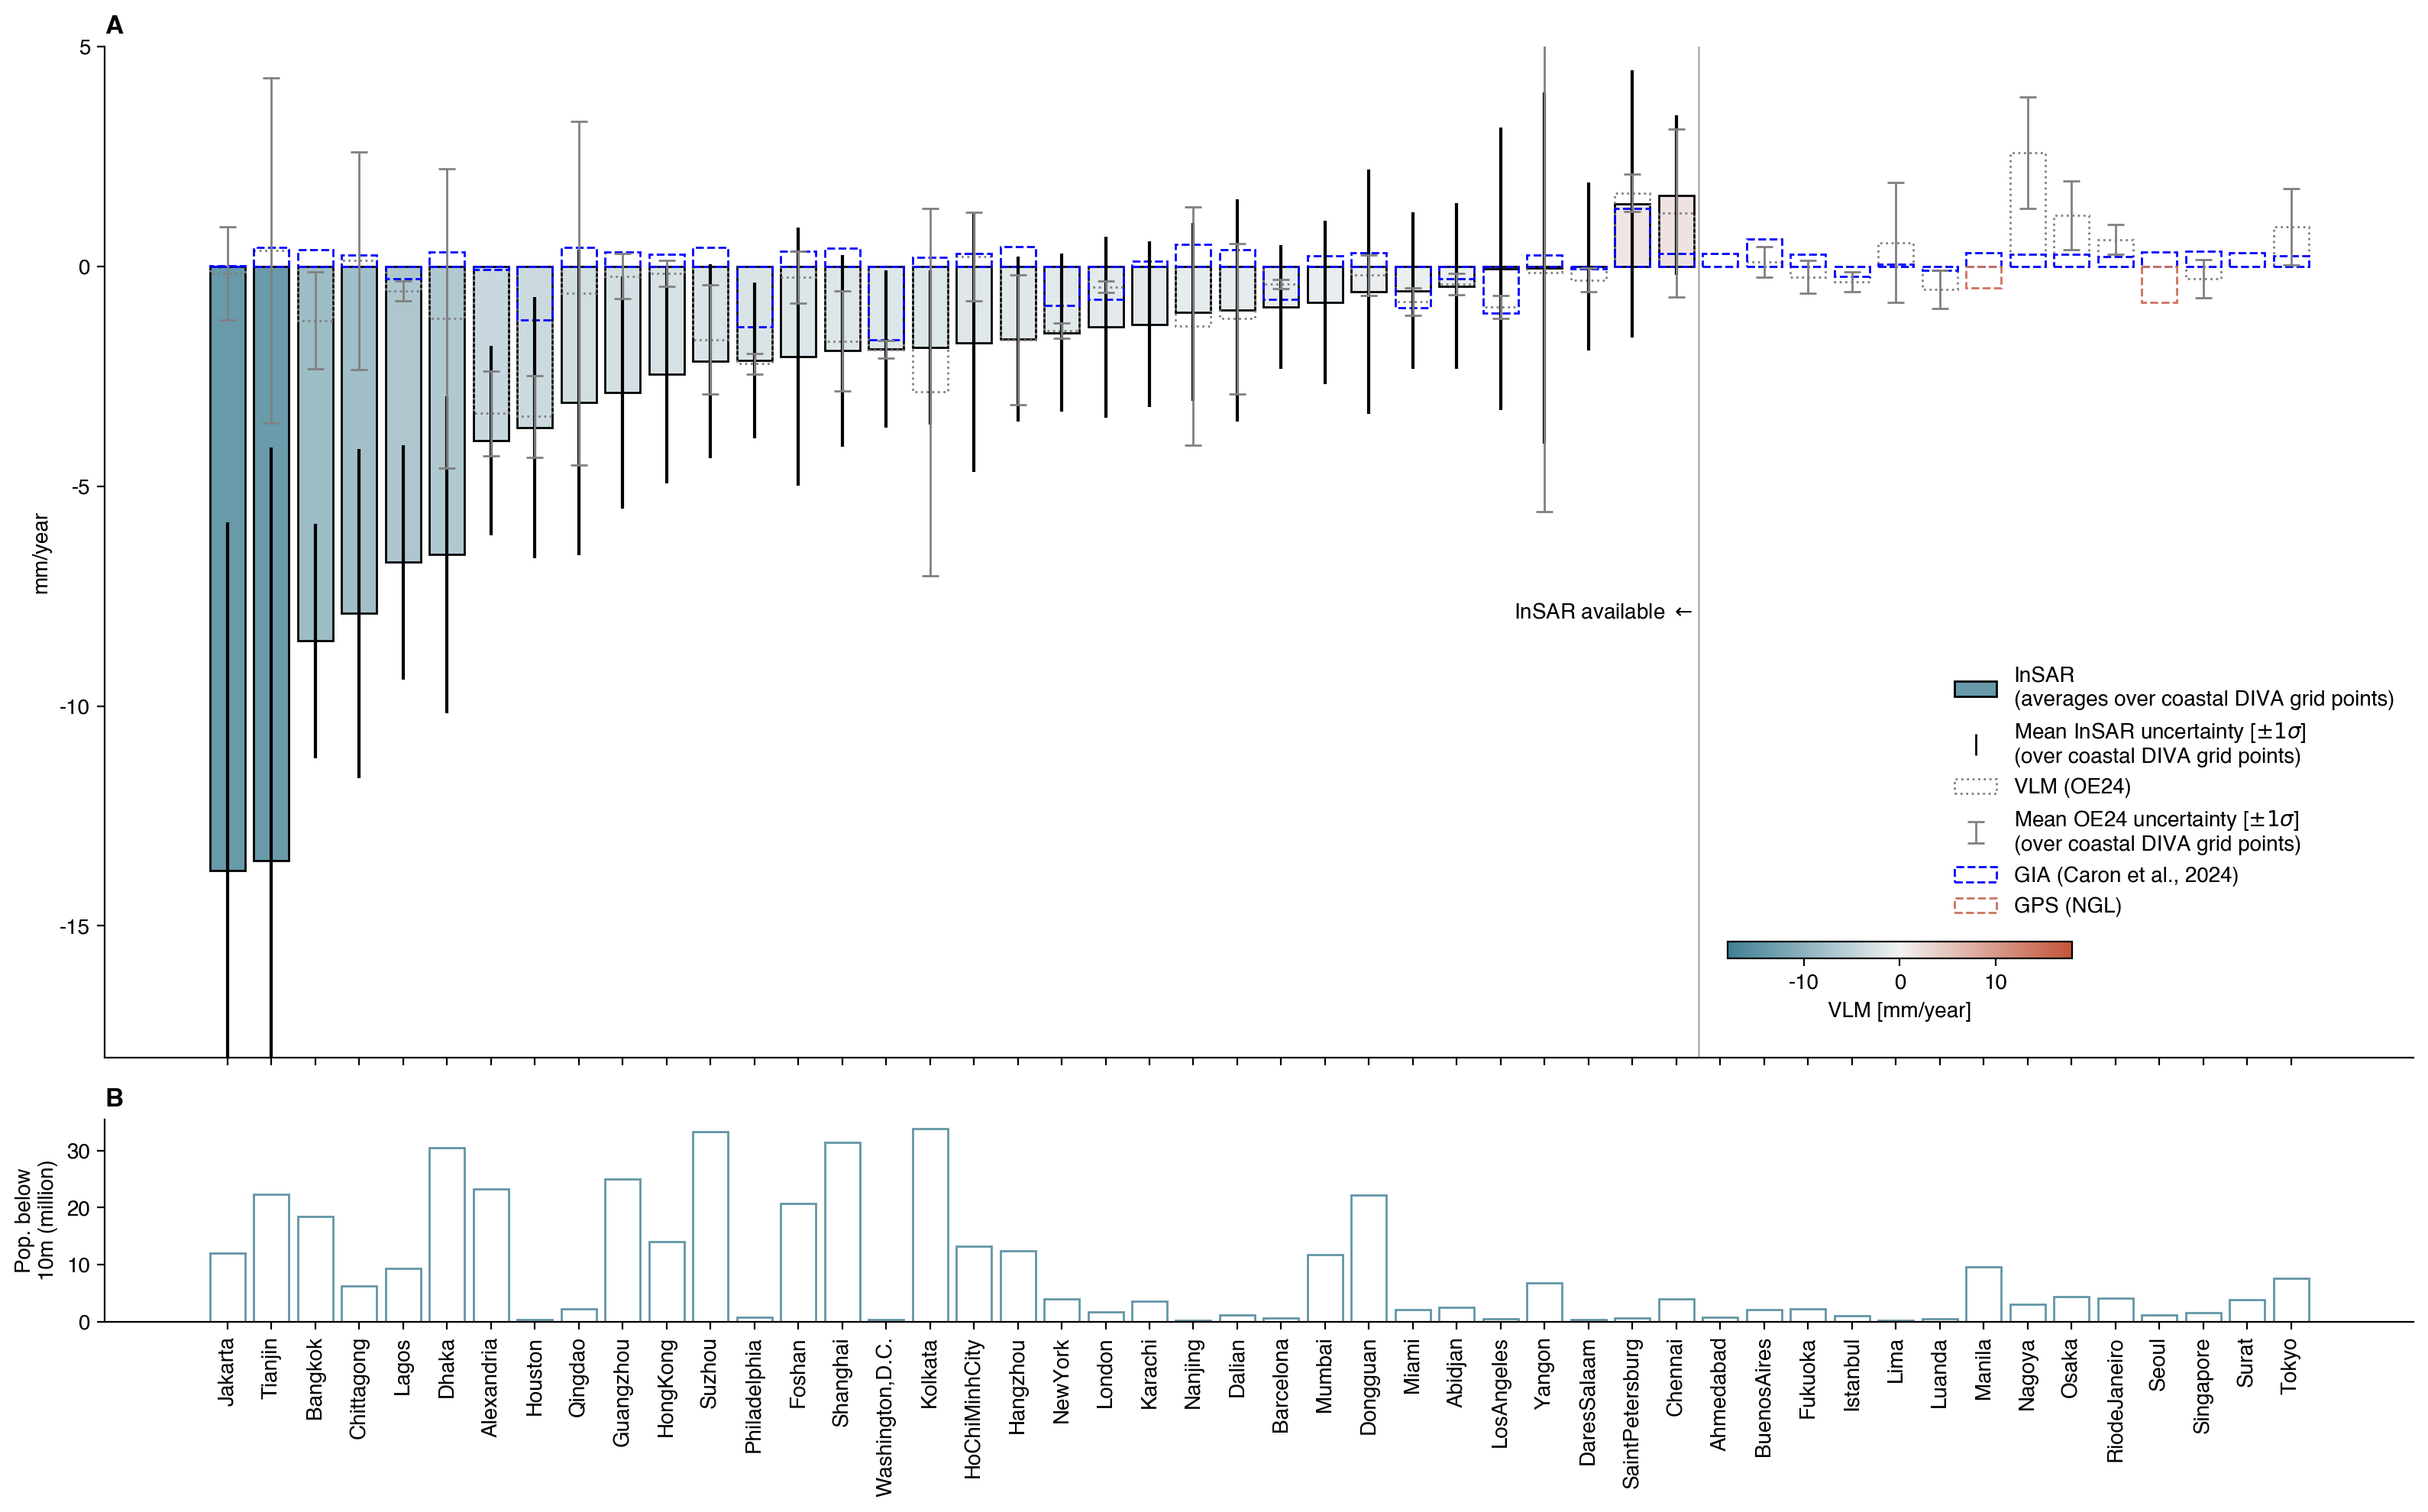

In [ ]:
fontsize_title = 12
fig,axs = plt.subplots(2,1,figsize=(16,10),gridspec_kw={'height_ratios':[1,0.2]},sharex=True)
ax=axs[0]
limits=[-18,18]
ax.grid(False)
val = 'VLM_InSAR3.03'
ax.bar(ALL_.index, ALL_[val]*1000.,color=cmap_err((ALL_[val]*1000.+limits[1])/(2*limits[1])),
       yerr=ALL_[val+'_uncertainty']*1000.,label='InSAR\n(averages over coastal DIVA grid points)',edgecolor='k')

val = 'VLM_map'
ax.bar(ALL_.index, ALL_[val]*1000.,fill=False,ecolor='grey',edgecolor='grey',label='VLM (OE24)',linestyle=':',yerr=ALL_[val+'_uncertainty']*1000.,capsize=0.1,error_kw={'capsize':4,'linewidth':1})



val = 'GIA'
ax.bar(ALL_.index, ALL_[val],fill=False,edgecolor='blue',linestyle='--',label='GIA (Caron et al., 2024)')

ax.vlines(29.5+4,-18,18,color='grey',linewidth = 0.5)
ax.text(29.5+4,-8,r'InSAR available $\leftarrow$ ',horizontalalignment='right',fontsize=10)

val = 'VLM_InSAR6'
ax.bar(ALL_.index[np.isnan(ALL_['VLM_InSAR3.03'])], ALL_[val][np.isnan(ALL_['VLM_InSAR3.03'])]*1000.,fill=False,edgecolor=cmap_err(0.9),label='GPS (NGL)',linestyle='--')
ax.set_title('A',loc='left',fontsize=fontsize_title,fontweight="bold")  

leg1 = ax.legend(loc='lower right')




unc_handle1 = ax.errorbar(
    [0], [20],
    yerr=[[1], [1]],
    fmt='none',
    ecolor='k',linewidth=1.5,
    elinewidth=1,
    capsize=0,
    label=r'Uncertainty [±1$\sigma$]'
)

unc_handle2 = ax.errorbar(
    [0], [20],
    yerr=[[1], [1]],
    fmt='none',
    ecolor='grey',
    elinewidth=1,
    capsize=4,
    label=r'Uncertainty [±1$\sigma$]'
)

# get auto legend entries already on ax
handles, labels = ax.get_legend_handles_labels()

# insert at index 1 and 3
handles.insert(1, unc_handle1)
labels.insert(1, r'Mean InSAR uncertainty [$\pm 1\sigma$]'+'\n'+'(over coastal DIVA grid points)')

handles.insert(3, unc_handle2)
labels.insert(3, r'Mean OE24 uncertainty [$\pm 1\sigma$]'+'\n'+'(over coastal DIVA grid points)')

ax.legend(handles[:-2], labels[:-2], loc='lower right', frameon=False, bbox_to_anchor=(1, 0.12))


sns.despine()
ax.set_ylim(limits[0],5)
ax.set_ylabel('mm/year')

ax=axs[1]
val = 'pop_below_10p0SUM'
ax.bar(ALL_.index, ALL_[val]/1000000,label='popullation below 10m',fill=False,edgecolor=cmap_err(0.1))
ax.set_ylabel('Pop. below\n10m (million)')
ax.set_title('B',loc='left',fontsize=fontsize_title,fontweight="bold")  



vmin, vmax = limits
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_err)
sm.set_array([])

axB = axs[0]
pos = axB.get_position()
height_frac = 0.3   # relative height of new axis
pad = 0.01          # vertical spacing


axB_top = fig.add_axes([
    pos.x0+0.585,
    pos.y1-0.57,
    pos.width/5.5,
    pos.height * height_frac
])


cbar = fig.colorbar(
    sm,
    ax= axB_top ,
    fraction=0.4,orientation='horizontal'
)
cbar.set_label('VLM [mm/year]')
axB_top.axis('off')

plt.setp(ax.xaxis.get_majorticklabels(), rotation=90 )
plt.tight_layout()
ax.grid(False)

plt.savefig(settings['plot_ext'] + 'SI3.png',bbox_inches='tight')
plt.savefig(settings['plot_ext'] + 'SI3.pdf',bbox_inches='tight')

plt.show()




## Save city data

In [ ]:
dir_Tay = settings['data_in'] +'InSAR_Tay/'


data_sets= []
cols_2 = [
    'file',
    'label',
    'mean',
    'median',
    'minus_1sigma',
    'plus_1sigma',
    'minus_2sigma',
    'plus_2sigma',
    'minus_3sigma',
    'plus_3sigma',
]
rows = []
names_not =[]

for file in files[:]:
    tay = xr.open_dataset(dir_Tay + file)
    print(file)
    box = [tay.lon.min()-2,tay.lon.max()+2,tay.lat.min()-2,tay.lat.max()+2]
    data = sl(only_InSAR).box(box).data

    limit = 50
    if file == 'BuenosAires_TD170_interpolated.nc':
        limit = 10
    if len(data.x)>0:
        if len(data.x)==1:
            data = xr.concat([data,data],dim='x')
        data['name'] = file[:-22]
        insar_x,data_x = sl(tay.x).couple(data.x,limit=limit)
        data = data.sel({'x':data_x.data.dropna(dim='x').astype(int).values})
        data_sets.append(data)
    else:
        names_not.append(file[:-22])
        print(file[:-22])
        print(tay.lon.min().values)
    found = False
    if 'Barcelona' not in file:
        for city_ins in All_Data_nc:
            
            if file_to_label[file] == city_ins['VLM'].long_name:
                print(city_ins['VLM'].long_name)
                vals = city_ins['VLM'].values/1000.
                vals = vals[np.isfinite(vals)]
                q = np.percentile(
                    vals,
                    [0.135, 2.275, 15.865, 50.0, 84.135, 97.725, 99.865]
                )
                rows.append([
                    file,
                    city_ins['VLM'].long_name,
                    float(np.mean(vals)),
                    float(q[3]),
                    float(q[2]),
                    float(q[4]),
                    float(q[1]),
                    float(q[5]),
                    float(q[0]),
                    float(q[6]),
                ])

                found = True
    if not found:          
        rows.append([file, '', np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan])

Alexandria_TD065_interpolated.nc
nearest
x
50
VLM Shirzaei Alexandria
Ahmedabad_TD034_interpolated.nc
nearest
x
50
Barcelona_TA132_interpolated.nc
nearest
x
50
Abidjan_TA118_interpolated.nc
nearest
x
50
VLM Shirzaei Abidjan
Bangkok_TD062_interpolated.nc
nearest
x
50
VLM Shirzaei Bangkok
BuenosAires_TD170_interpolated.nc
nearest
x
10
Chennai_TD092_interpolated.nc
nearest
x
50
VLM Shirzaei Chennai
Chittagong_TD077_interpolated.nc
nearest
x
50
Dalian_TA098_interpolated.nc
nearest
x
50
DaresSalaam_TD006_interpolated.nc
nearest
x
50
VLM Shirzaei DarEsSalaam
Dhaka_TD150_interpolated.nc
nearest
x
50
Dongguan_TA011_interpolated.nc
nearest
x
50
Foshan_TA011_interpolated.nc
nearest
x
50
Fukuoka_TD163_interpolated.nc
nearest
x
50
Guangzhou_TA011_interpolated.nc
nearest
x
50
VLM Shirzaei Guangzhou
Hangzhou_TA069_interpolated.nc
nearest
x
50
HoChiMinhCity_TD018_interpolated.nc
nearest
x
50
VLM Shirzaei HoChiMinh
HongKong_TA011_interpolated.nc
nearest
x
50
Houston_TD143_interpolated.nc
nearest
x
50


In [ ]:
files = [
    'Alexandria_TD065_interpolated.nc',
    'Ahmedabad_TD034_interpolated.nc',
    'Barcelona_TA132_interpolated.nc',
    'Abidjan_TA118_interpolated.nc',
    'Bangkok_TD062_interpolated.nc',
    'BuenosAires_TD170_interpolated.nc',
    'Chennai_TD092_interpolated.nc',
    'Chittagong_TD077_interpolated.nc',
    'Dalian_TA098_interpolated.nc',
    'DaresSalaam_TD006_interpolated.nc',
    'Dhaka_TD150_interpolated.nc',
    'Dongguan_TA011_interpolated.nc',
    'Foshan_TA011_interpolated.nc',
    'Fukuoka_TD163_interpolated.nc',
    'Guangzhou_TA011_interpolated.nc',
    'Hangzhou_TA069_interpolated.nc',
    'HoChiMinhCity_TD018_interpolated.nc',
    'HongKong_TA011_interpolated.nc',
    'Houston_TD143_interpolated.nc',
    'Istanbul_TD138_interpolated.nc',
    'Jakarta_TA098_interpolated.nc',
    'Karachi_TD078_interpolated.nc',
    'Kolkata_TD048_interpolated.nc',
    'Lagos_TD095_interpolated.nc',
    'Lima_TD069_interpolated.nc',
    'London_TD081_interpolated.nc',
    'LosAngeles_TD071_interpolated.nc',
    'Luanda_TA131_interpolated.nc',
    'Manila_TD032_interpolated.nc',
    'Miami_TA048_interpolated.nc',
    'Mumbai_TD034_interpolated.nc',
    'Nagoya_TD119_interpolated.nc',
    'Nanjing_TA069_interpolated.nc',
    'NewYork_TA033_interpolated.nc',
    'Osaka_TD017_interpolated.nc',
    'Philadelphia_TA106_interpolated.nc',
    'Qingdao_TD076_interpolated.nc',
    'RiodeJaneiro_TD155_interpolated.nc',
    'SaintPetersburg_TD007_interpolated.nc',
    'Seoul_TD134_interpolated.nc',
    'Shanghai_TA171_interpolated.nc',
    'Singapore_TD018_interpolated.nc',
    'Surat_TD034_interpolated.nc',
    'Suzhou_TA171_interpolated.nc',
    'Tianjin_TD149_interpolated.nc',
    'Tokyo_TD046_interpolated.nc',
    'Washington,D.C._TA004_interpolated.nc',
    'Yangon_TD033_interpolated.nc',
]
# from Tay

city_to_label = {
    'Abidjan': 'VLM Shirzaei Abidjan',
    'Alexandria': 'VLM Shirzaei Alexandria',
    'Bangkok': 'VLM Shirzaei Bangkok',
    'Chennai': 'VLM Shirzaei Chennai',
    'DaresSalaam': 'VLM Shirzaei DarEsSalaam',
    'Guangzhou': 'VLM Shirzaei Guangzhou',
    'HoChiMinhCity': 'VLM Shirzaei HoChiMinh',
    'Houston': 'VLM Shirzaei Houston',
    'Jakarta': 'VLM Shirzaei Jakarta',
    'Kolkata': 'VLM Shirzaei Kolkata',
    'Lagos': 'VLM Shirzaei Lagos',
    'LosAngeles': 'VLM Shirzaei LosAngeles',
    'Mumbai': 'VLM Shirzaei Mumbai',
    'NewYork': 'VLM Shirzaei NewYork',
    'SaintPetersburg': 'VLM Shirzaei SaintPetersburg',
    'Shanghai': 'VLM Shirzaei Shanghai',
    'Yangon': 'VLM Shirzaei Yangon',
}

file_to_label = {
    f: city_to_label.get(f.split('_')[0], '')
    for f in files
}
file_to_label


{'Alexandria_TD065_interpolated.nc': 'VLM Shirzaei Alexandria',
 'Ahmedabad_TD034_interpolated.nc': '',
 'Barcelona_TA132_interpolated.nc': '',
 'Abidjan_TA118_interpolated.nc': 'VLM Shirzaei Abidjan',
 'Bangkok_TD062_interpolated.nc': 'VLM Shirzaei Bangkok',
 'BuenosAires_TD170_interpolated.nc': '',
 'Chennai_TD092_interpolated.nc': 'VLM Shirzaei Chennai',
 'Chittagong_TD077_interpolated.nc': '',
 'Dalian_TA098_interpolated.nc': '',
 'DaresSalaam_TD006_interpolated.nc': 'VLM Shirzaei DarEsSalaam',
 'Dhaka_TD150_interpolated.nc': '',
 'Dongguan_TA011_interpolated.nc': '',
 'Foshan_TA011_interpolated.nc': '',
 'Fukuoka_TD163_interpolated.nc': '',
 'Guangzhou_TA011_interpolated.nc': 'VLM Shirzaei Guangzhou',
 'Hangzhou_TA069_interpolated.nc': '',
 'HoChiMinhCity_TD018_interpolated.nc': 'VLM Shirzaei HoChiMinh',
 'HongKong_TA011_interpolated.nc': '',
 'Houston_TD143_interpolated.nc': 'VLM Shirzaei Houston',
 'Istanbul_TD138_interpolated.nc': '',
 'Jakarta_TA098_interpolated.nc': 'VLM Shir

In [196]:
cols = ['VLM_InSAR3.03','VLM_InSAR3.03_uncertainty','pop_below_10p0','GIA','VLM_map','VLM_map_uncertainty','VLM_InSAR6','VLM_InSAR6_uncertainty']

data_out = xr.concat(data_sets,dim='x')
MEAN = data_out.groupby('name').mean()[cols].to_dataframe()
STD = data_out.groupby('name').std()[cols].to_dataframe()
STD.columns = [col + '_std' for col in STD.columns]
SUM = data_out.groupby('name').sum()[cols].to_dataframe()
SUM.columns = [col + 'SUM' for col in SUM.columns]
ALL_ = pd.concat([MEAN,STD,SUM],axis=1)# .sort_values(by='VLM_InSAR3.03')

rows_df = pd.DataFrame(rows, columns=cols_2)

# use file name or city label as index only if it matches ALL_
# otherwise just align by row order:
rows_df.index = [file[:-22] for file in rows_df['file'].values]
rows_df = rows_df.sort_index()
# optional: drop duplicate metadata columns if you do not want them
# rows_df = rows_df.drop(columns=['file', 'label'])

# add all new columns to ALL_
for c in rows_df.columns:
    ALL_[c] = rows_df[c].values
ALL_ = ALL_.sort_values(by='VLM_InSAR3.03')

In [216]:
ALL_save = copy.deepcopy(ALL_)
col_sel = ['VLM_InSAR3.03', 'VLM_InSAR3.03_uncertainty',
            'VLM_map', 'VLM_map_uncertainty','mean', 'median',
             'plus_1sigma','plus_2sigma','plus_3sigma', 'minus_1sigma', 'minus_2sigma',
            'minus_3sigma','GIA', 'pop_below_10p0']
ALL_save=ALL_save[col_sel]

rename_cols = ['Mean InSAR VLM¹', 'Mean InSAR VLM uncertainties¹',
            'Mean OE24 VLM¹', 'Mean OE24 VLM uncertainties¹','Mean InSAR VLM (Shirzaei et al., 2024²)', 'Median InSAR VLM (Shirzaei et al., 2024²)',
            'p84.135 [+1σ]²', 'p97.725 [+2σ]²', 'p99.865 [+3σ]²', 'p15.865 [-1σ]²', 'p2.275 [-2σ]²', 'p0.135 [-3σ]²','GIA (Caron et al., 2018)', 'LECZ population (Nicholls et al., 2021)']

ALL_save.columns = rename_cols
ALL_save[rename_cols[:-2]]=ALL_save[rename_cols[:-2]]*1000.
ALL_save[rename_cols[-1:]] = np.round(ALL_save[rename_cols[-1:]])
ALL_save= np.round(ALL_save,2)
ALL_save.replace(np.nan,'-').to_csv('./data/City_VLM_comparison.csv')


# SI Figure 9

0.0 InSAR Cities
1.0 InSAR NZ
2.0 InSAR China
3.0 InSAR USA
4.0 InSAR EU
5.0 InSAR Deltas
6.0 Mississippi
7.0 GNSS
8.0 OE24
9.0 GIA


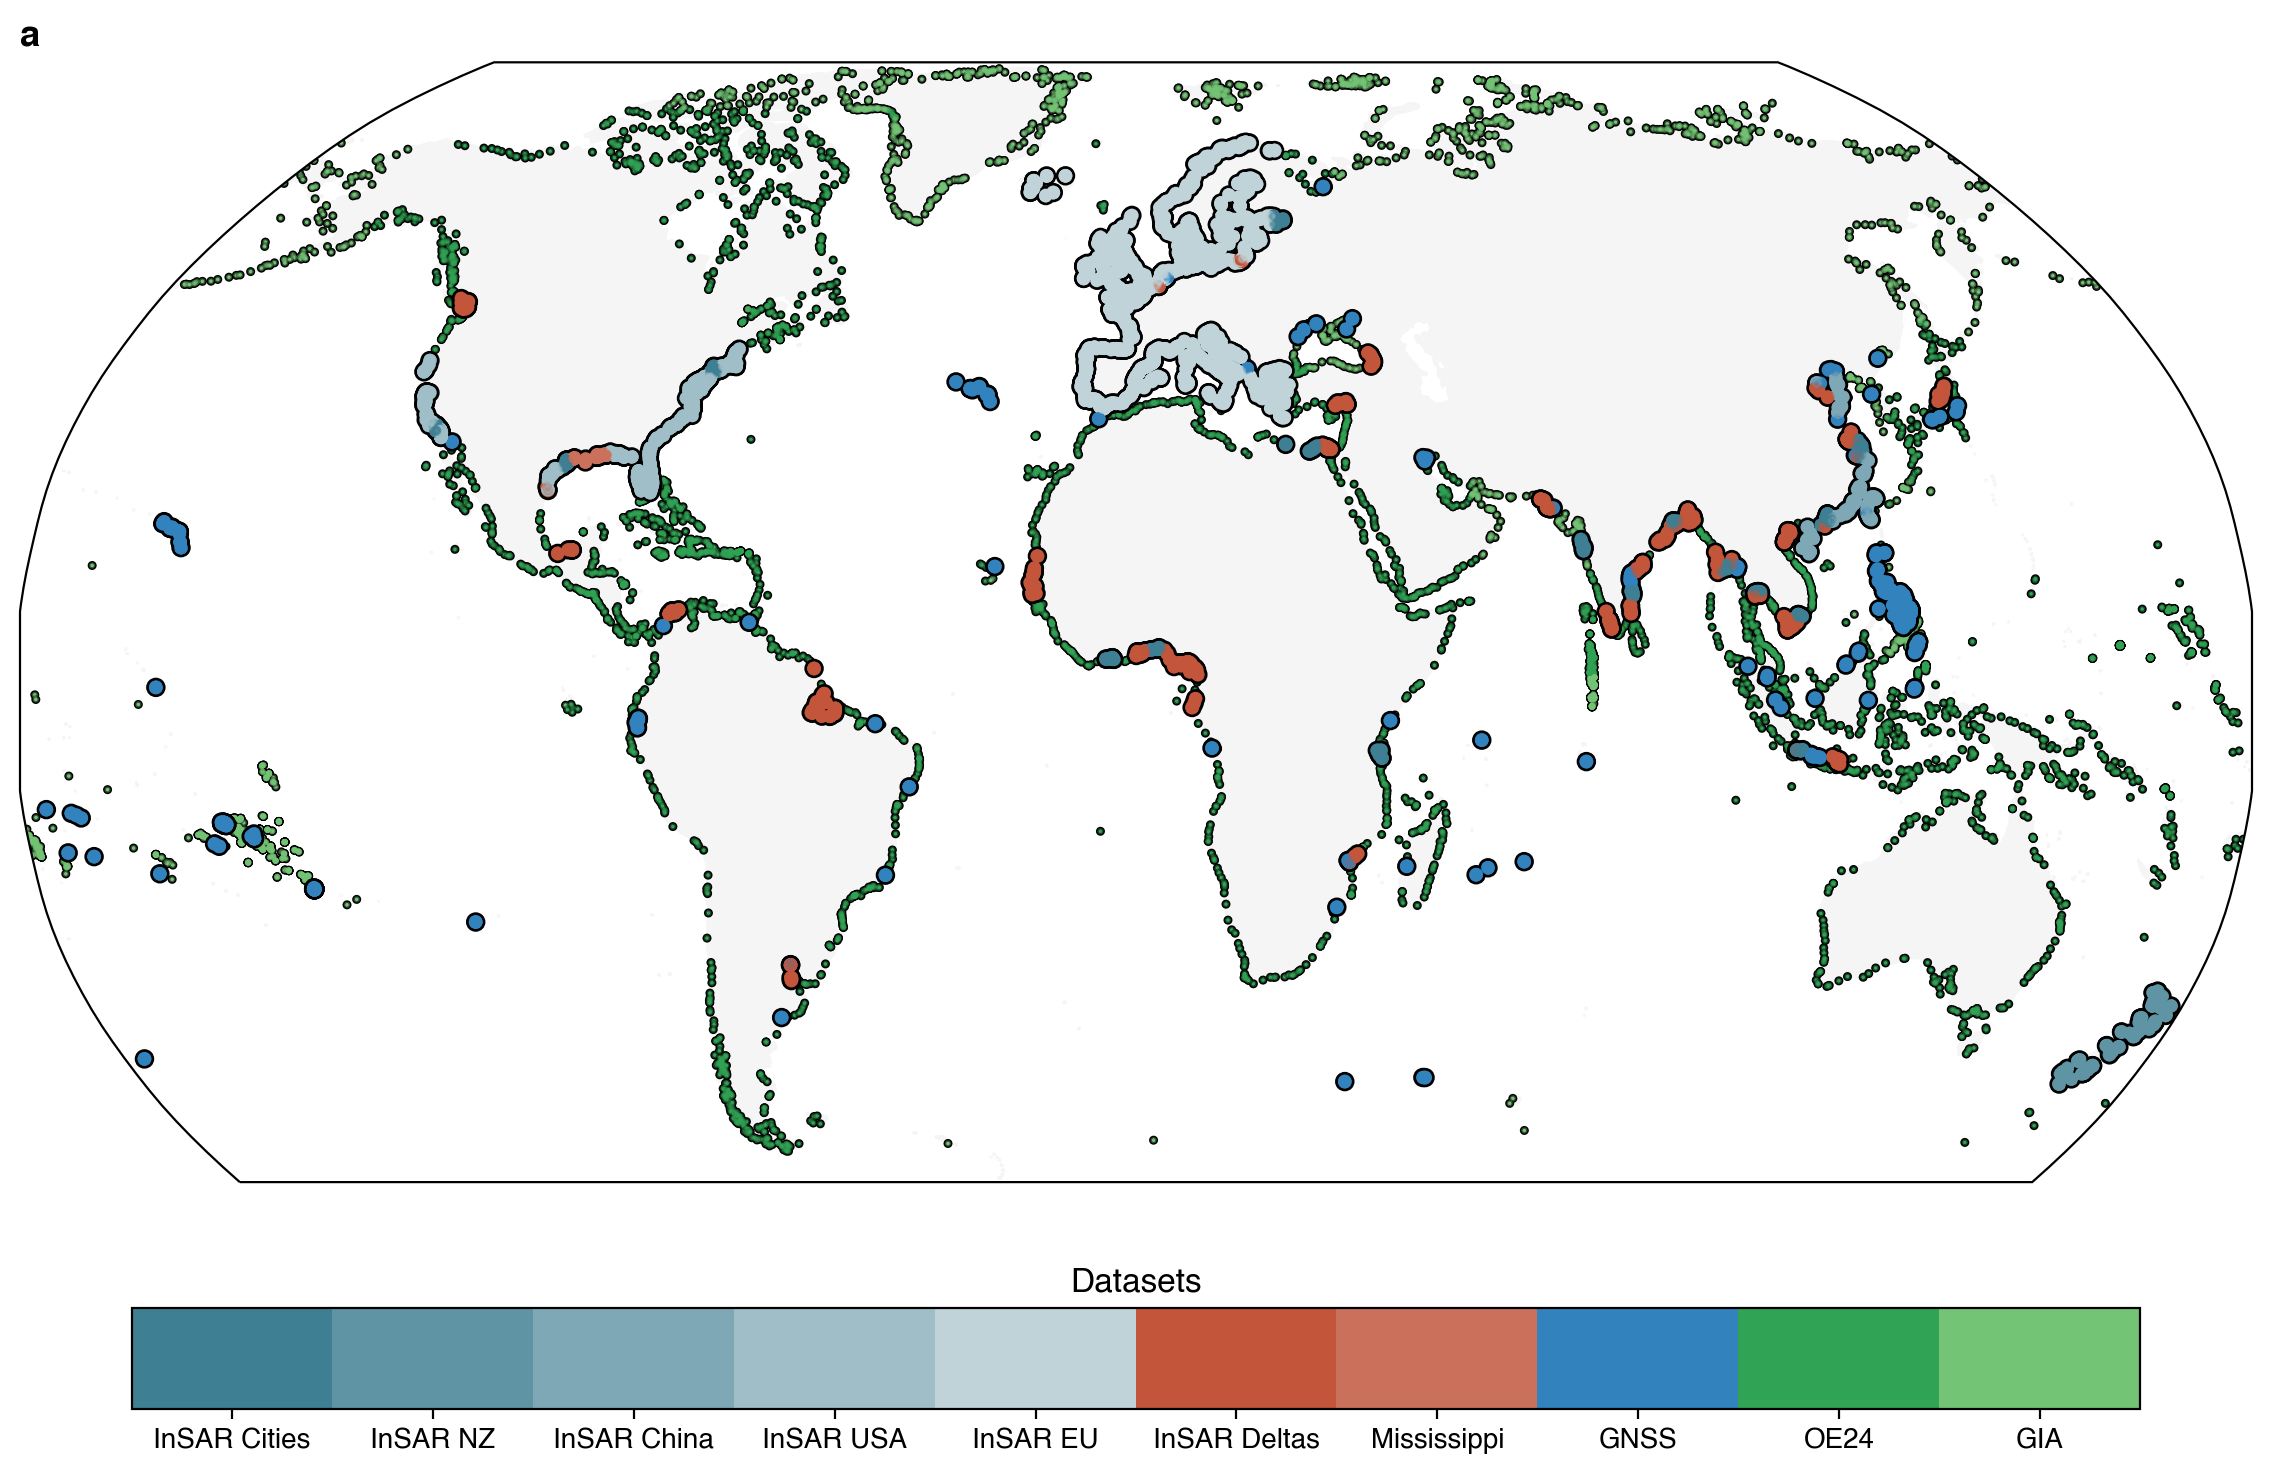

In [16]:
scaler_factor = 1
proj =ccrs.Robinson(central_longitude=0, globe=None)


fig = plt.figure(figsize=(max_width,max_width*(12/16)),constrained_layout=True,edgecolor='black')
factor=3
number_of_plots = 4
xp = 1
yp=1
gs = gridspec.GridSpec(16*factor, 12*factor,wspace=0.0, hspace=0.0,top = 1, bottom = 0, right = 0.98, left = 0.05)

units = ['mm/year','mm/year','mm/year']
cbar_extends = ['both','both','both']

ii=0
jj=0


ax = fig.add_subplot(gs[:,:],projection = proj)

cmap_err = sns.diverging_palette(220, 20, as_cmap=True)
# Get base pastel colormap

base = cm.get_cmap('tab20c')
rgba_tail = np.hstack([base.colors[8:10], np.ones((2, 1))])
rgba_p = np.hstack([base.colors[:1], np.ones((1, 1))])

colors =np.concatenate([cmap_err(np.arange(5)/11),cmap_err(1-np.arange(2)/11),rgba_p,rgba_tail])

cmap_err = ListedColormap(colors, name='Pastel4')
limts=[-0.5,9.5]

size_map = 0.1
aspect= 1.15

ax,imr = plot_map_ax_mapping(ax,ds_grouped['datatype_show'],region='custom',
                            msize=size_map,land_facecolor='whitesmoke',aspect=aspect,
            scalecolor=False,label='',extend=[-179,179,-60,85],minv = limts[0],maxv = limts[1],alpha=1,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,msize_frac=0.3) 


size_map = 5
aspect= 1.15
ax,im = plot_map_ax_mapping(ax,ds_grouped['datatype_show'][ds_grouped['datatype_show']>7],region='custom',
                            msize=size_map,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['k'],
            scalecolor=False,label='',extend=[-179,179,-60,85],minv = limts[0],maxv = limts[1],alpha=1,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,msize_frac=0.3) 


size_map = 12*3
aspect= 1.15
ax,im = plot_map_ax_mapping(ax,ds_grouped['datatype_show'][ds_grouped['datatype_show']<8],region='custom',
                            msize=size_map,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['k'],
            scalecolor=False,label='',extend=[-179,179,-60,85],minv = limts[0],maxv = limts[1],alpha=1,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,msize_frac=0.3) 

size_map = 8*3
aspect= 1.15
ax,im = plot_map_ax_mapping(ax,ds_grouped['datatype_show'][ds_grouped['datatype_show']<8],region='custom',
                            msize=size_map,land_facecolor='whitesmoke',aspect=aspect,edgecolor=['None'],
            scalecolor=False,label='',extend=[-179,179,-60,85],minv = limts[0],maxv = limts[1],alpha=1,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,msize_frac=0.3) 


ax.set_rasterized('rasterized')
ax.axis('off')
ax.set_title('a',fontweight='bold',fontsize=main_fontsize,loc='left')

clb =plt.colorbar(imr,ax=ax,orientation = 'horizontal',shrink=0.9)
clb.ax.set_title('Datasets',fontsize=labelsize)

names = []
settings['datatypes_info2'] = { '0':['InSAR Cities',1.72],
                               '1':['InSAR NZ',1.6],
                               '2':['InSAR China',1.5],
                               '3':['InSAR USA',1.43],
                               '4':['InSAR EU',1.19],
                               '5':['InSAR Deltas',1.2],
                               '6':['Mississippi',0], # RSET-based
                               '7':['GNSS',0],
                               '8':['OE24',0],
                               '9':['GIA',0]}
for (id,d) in settings['datatypes_info2'].items():
    print(float(id),d[0])
    names.append(d[0])

clb.set_ticks(np.arange(10))
clb.set_ticklabels(names)
pos = clb.ax.get_position()       # current position
clb.ax.set_position([
    pos.x0,
    pos.y0 + 0.08,                 # shift upward (increase)
    pos.width,
    pos.height
])

ax.set_rasterized('rasterized')
ax.axis('off')
plt.axis('on')

plt.savefig(settings['plot_ext'] + 'SI9.png',bbox_inches='tight')
plt.savefig(settings['plot_ext'] + 'SI9.pdf',bbox_inches='tight')

plt.show()
